# NileGuard — Master Preprocessing (File 1 of 2)
Loads the raw TerraClimate tensor, integrates governorates, validates, masks,
winsorises, scales, and exports `final_nileguard_tensor.npy` for the modelling
notebook.

### Production Standards & First-Differencing Architecture:
- **First-Order Differencing (d=1)**: Enforced on PDSI to break heavy month-to-month autocorrelation and capture abrupt climate transition shocks.
- **ACF/PACF on Delta Series**: Autocorrelation and PACF lag extractions are strictly calculated on the differenced series (d=1).
- **Target Integrity**: PDSI is accurately isolated as target Y via dynamic index resolution.
- **Zero Temporal Leakage**: RobustScalers are fitted strictly on historical data (<= 2005) before transforming validation/test sets.
- **Sliding-Window Sequences**: Generates (t-L ... t-1) -> (t ... t+H-1) pairs for ConvLSTM/Transformer models.

## Phase 1 — Environment & Data Loading

In [1]:
import os
import warnings
from pathlib import Path
from dataclasses import dataclass, field
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
import joblib
# Fix OpenMP duplicate runtime conflicts on Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# --- Configuration ---
@dataclass
class NileGuardConfig:
    project_root: Path = Path('D:/Climate_Project')
    output_dir: Path = project_root / 'output'
    fig_dir: Path = output_dir / 'figures'
    
    # File paths
    tensor_path: Path = output_dir / "climate14july_tensor_final.npy"
    vars_path: Path = output_dir / "features14july_names.npy"
    lat_path: Path = output_dir / "lat14july.npy"
    lon_path: Path = output_dir / "lon14july.npy"
    spatial_mask_path: Path = output_dir / "v4_spatial_mask.npy"
    gov_mask_path: Path = output_dir / "v4_final_gov_mask.npy"
    shp_path: Path = project_root / 'data' / 'shapefiles' / 'gadm41_EGY_1.shp'
    
    # Fallback paths for local scratch testing
    local_tensor_path: Path = Path("climate14july_tensor_final.npy")
# --- Environment Setup ---
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})
# --- Data Loader Class ---
class NileDataLoader:
    def __init__(self, config: NileGuardConfig):
        self.config = config
        
    def load_workspace(self):
        """Loads all generated assets into memory or builds synthetic fallback."""
        if self.config.tensor_path.exists():
            assets = {
                "tensor": np.load(str(self.config.tensor_path), mmap_mode="r", allow_pickle=True),
                "vars": np.load(str(self.config.vars_path), allow_pickle=True) if self.config.vars_path.exists() else np.array([
                    "aet", "def", "PDSI", "pet", "ppt", "q", "soil", "srad", "swe", "tmax", "tmin", "vap", "vpd", "ws"
                ]),
                "lat": np.load(str(self.config.lat_path), allow_pickle=True) if self.config.lat_path.exists() else np.linspace(22, 32, 144),
                "lon": np.load(str(self.config.lon_path), allow_pickle=True) if self.config.lon_path.exists() else np.linspace(25, 35, 72),
                "spatial_mask": np.load(str(self.config.spatial_mask_path), allow_pickle=True) if self.config.spatial_mask_path.exists() else np.ones((144, 72)),
                "gov_mask": np.load(str(self.config.gov_mask_path), allow_pickle=True) if self.config.gov_mask_path.exists() else np.zeros((144, 72))
            }
        else:
            print("Path D:/ not mounted. Creating standardized TerraClimate validation workspace...")
            T, H, W, F = 768, 144, 72, 14
            np.random.seed(42)
            assets = {
                "tensor": np.random.randn(T, H, W, F).astype("float32"),
                "vars": np.array(["aet", "def", "PDSI", "pet", "ppt", "q", "soil", "srad", "swe", "tmax", "tmin", "vap", "vpd", "ws"]),
                "lat": np.linspace(22, 32, H),
                "lon": np.linspace(25, 35, W),
                "spatial_mask": np.ones((H, W)),
                "gov_mask": np.zeros((H, W))
            }
        
        # Verify integrity
        for name, data in assets.items():
            print(f"Loaded {name:15s} | Shape: {data.shape}")
        
        return assets
# --- Execution ---
config = NileGuardConfig()
loader = NileDataLoader(config)
data = loader.load_workspace()
print("Environment ready for analysis.")


Loaded tensor          | Shape: (768, 144, 72, 14)
Loaded vars            | Shape: (13,)
Loaded lat             | Shape: (144,)
Loaded lon             | Shape: (72,)
Loaded spatial_mask    | Shape: (144, 72)
Loaded gov_mask        | Shape: (144, 72)
Environment ready for analysis.


In [2]:
data = loader.load_workspace()
    
feature_names = list(data["vars"])
print("=== Features Order from Loaded File ===")
for idx, feat in enumerate(feature_names):
    print(f"Index [{idx}] -> {feat}")
        
print("Environment ready for analysis.")

Loaded tensor          | Shape: (768, 144, 72, 14)
Loaded vars            | Shape: (13,)
Loaded lat             | Shape: (144,)
Loaded lon             | Shape: (72,)
Loaded spatial_mask    | Shape: (144, 72)
Loaded gov_mask        | Shape: (144, 72)
=== Features Order from Loaded File ===
Index [0] -> aet
Index [1] -> def
Index [2] -> PDSI
Index [3] -> pet
Index [4] -> ppt
Index [5] -> q
Index [6] -> soil
Index [7] -> srad
Index [8] -> tmax
Index [9] -> tmin
Index [10] -> vap
Index [11] -> vpd
Index [12] -> ws
Environment ready for analysis.


In [3]:
from dataclasses import dataclass, field
from pathlib import Path
import numpy as np
@dataclass
class NileGuardConfig:
    # --- Project Infrastructure ---
    project_root: Path = Path.cwd()
    output_dir: Path = project_root / "output"
    fig_dir: Path = output_dir / "figures"
    
    # --- File Paths ---
    tensor_path: Path = output_dir / "climate14july_tensor_final.npy"
    vars_path: Path = output_dir / "features14july_names.npy"
    spatial_mask_path: Path = output_dir / "v4_spatial_mask.npy"
    gov_mask_path: Path = output_dir / "v4_final_gov_mask.npy"
    shp_path: Path = Path('D:/Climate_Project/data/shapefiles/gadm41_EGY_1.shp')
    
    # --- Feature & Governorate Registry ---
    feature_names: list = field(default_factory=list)
    gov_map: dict = field(default_factory=lambda: {
        1: "Fayoum", 2: "Minya", 3: "Luxor", 4: "Aswan",
        5: "Asyut", 6: "Beni_Suef", 7: "Qena", 8: "Sohag",
    })
    
    # --- Metadata ---
    pdsi_idx: int = 0
    n_feats: int = 0
    gov_ch: int = 14
    
    def __post_init__(self):
        self.fig_dir.mkdir(parents=True, exist_ok=True)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        
        # Load feature names dynamically
        if self.vars_path.exists():
            loaded_vars = np.load(self.vars_path, allow_pickle=True)
            self.feature_names = [str(v) for v in loaded_vars]
        else:
            self.feature_names = [
                "aet", "def", "PDSI", "pet", "ppt", "q", 
                "soil", "srad", "swe", "tmax", "tmin", "vap", "vpd", "ws"
            ]
        self.n_feats = len(self.feature_names)
        if "PDSI" in self.feature_names:
            self.pdsi_idx = self.feature_names.index("PDSI")
        else:
            raise ValueError("PDSI not found in loaded feature names!")
# Initialize configuration
config = NileGuardConfig()
# --- Tensor Loading & Validation ---
def load_and_validate_tensor(cfg: NileGuardConfig):
    tensor = data["tensor"]
    T, H, W, F = tensor.shape
    
    print("Tensor Analysis:")
    print(f"- Dimensions: {T} (Time) x {H} (Height) x {W} (Width) x {F} (Features)")
    print(f"- Data Type: {tensor.dtype}")
    print(f"- Memory Usage: {tensor.nbytes/1024**2:.1f} MB")
    
    assert (H, W) == (144, 72), f"Spatial dimensions mismatch. Expected (144, 72), found ({H}, {W})"
    assert F == cfg.n_feats, f"Features count mismatch between tensor ({F}) and config ({cfg.n_feats})"
    print("Spatial and Feature dimensions validation passed.")
    return tensor
tensor = load_and_validate_tensor(config)
print(f" Registry Status:")
print(f"  Feature count : {config.n_feats}")
print(f"  PDSI index    : {config.pdsi_idx} (Target Confirmed)")
print(f"  Gov channel   : {config.gov_ch}")


Tensor Analysis:
- Dimensions: 768 (Time) x 144 (Height) x 72 (Width) x 14 (Features)
- Data Type: float32
- Memory Usage: 425.2 MB
Spatial and Feature dimensions validation passed.
 Registry Status:
  Feature count : 14
  PDSI index    : 2 (Target Confirmed)
  Gov channel   : 14


In [4]:
import numpy as np

# 1. Ensure dimensions are defined from current tensor
T, H, W, F = tensor.shape
print(f"Current Tensor Shape: {tensor.shape}")

# 2. Match Upper-Egypt Governorates and Rasterize
if config.shp_path.exists():
    import geopandas as gpd
    from rasterio.transform import from_bounds
    from rasterio.features import rasterize
    
    try:
        gdf = gpd.read_file(str(config.shp_path))
    except Exception:
        gdf = gpd.read_file(str(config.shp_path), layer="gadm41_EGY_1")

    gdf = gdf.to_crs(epsg=4326).reset_index(drop=True)
    UE_KEYWORDS = ["aswan", "asyut", "assiut", "suwayf", "fayyum", "fayoum", "minya",
                   "suhaj", "sohag", "sawhaj", "qina", "qena", "kena", "uqsur", "luxor"]

    is_ue = gdf["NAME_1"].apply(lambda n: any(k in str(n).lower() for k in UE_KEYWORDS))
    ue = gdf[is_ue].reset_index(drop=True)
    if len(ue) == 0:
        ue = gdf
    print(f"Matched {len(ue)} governorates: {sorted(ue['NAME_1'].tolist())}")

    lon_min, lat_min, lon_max, lat_max = ue.total_bounds
    transform = from_bounds(lon_min, lat_min, lon_max, lat_max, width=W, height=H)

    shapes = [(geom, i+1) for i, geom in enumerate(ue.geometry)]
    governorate_mask = rasterize(shapes, out_shape=(H, W), transform=transform, 
                                 fill=0, dtype="int32").astype("float32")
else:
    print("Creating synthetic Upper Egypt governorate grid mask for verification.")
    governorate_mask = np.zeros((H, W), dtype="float32")
    for g_id in range(1, 9):
        governorate_mask[(g_id-1)*(H//8):g_id*(H//8), W//4:3*W//4] = g_id

# 5. Integration: Append Governorate channel to tensor
gov_channel = np.broadcast_to(governorate_mask[np.newaxis, :, :, np.newaxis], (T, H, W, 1))
tensor = np.concatenate([tensor, gov_channel], axis=-1)

# 6. Final Validation
assert tensor.shape == (T, H, W, 15), f"Expected (T, 144, 72, 15), found {tensor.shape}"
print(f"Integration complete. Final tensor shape: {tensor.shape}")

Current Tensor Shape: (768, 144, 72, 14)
Matched 8 governorates: ['Al Fayyum', 'Al Minya', 'Al Uqsur', 'Aswan', 'Asyut', 'Bani Suwayf', 'Qina', 'Suhaj']
Integration complete. Final tensor shape: (768, 144, 72, 15)


## Data Quality Report (raw tensor, before EDA/masking)

In [5]:
# Check the actual number of features in the tensor
print(f"Tensor shape: {tensor.shape}")
print(f"Number of features in tensor: {tensor.shape[-1]}")

Tensor shape: (768, 144, 72, 15)
Number of features in tensor: 15


In [6]:
import pandas as pd
import xarray as xr
import numpy as np
import gc
# 1. Define all feature channels
features = [
    "aet", "def", "PDSI", "pet", "ppt", "q", 
    "soil", "srad", "swe", "tmax", "tmin", "vap", "vpd", "ws", "governorate" 
]
climate_vars = [f for f in features if f != "governorate"]
# 2. Define coordinates and create lightweight Xarray DataArray wrapper
T_coords = pd.date_range(start="1958-01-01", periods=tensor.shape[0], freq="ME") 
lat_coords = np.linspace(22, 32, tensor.shape[1]) 
lon_coords = np.linspace(25, 35, tensor.shape[2]) 
feat_names_matched = features[:tensor.shape[-1]]
da_full = xr.DataArray(
    tensor, 
    dims=("time", "lat", "lon", "feature"),
    coords={
        "time": T_coords,
        "lat": lat_coords,
        "lon": lon_coords,
        "feature": feat_names_matched
    },
    name="NileGuard_Data"
)
# 3. Memory-Safe Data Quality Report (In-Place Slice Streaming)
rows, total_nan = [], 0
for idx, f in enumerate(climate_vars):
    if idx < tensor.shape[-1]:
        feat_slice = tensor[..., idx]
        nan_count = int(np.isnan(feat_slice).sum())
        total_nan += nan_count
        
        f_mean = float(np.nanmean(feat_slice))
        f_std  = float(np.nanstd(feat_slice))
        f_min  = float(np.nanmin(feat_slice))
        f_max  = float(np.nanmax(feat_slice))
        
        rows.append({
            "Feature": f,
            "Mean": round(f_mean, 3),
            "Std": round(f_std, 3),
            "Min": round(f_min, 3),
            "Max": round(f_max, 3),
            "NaN Count": nan_count,
            "NaN %": round(100 * nan_count / feat_slice.size, 3)
        })
print("=========================================================================")
print("             PHYSICAL CLIMATE FEATURES DATA QUALITY REPORT               ")
print("=========================================================================")
print(pd.DataFrame(rows).set_index("Feature").to_string())
print(f"\nTOTAL NaNs: {total_nan}" + ("  (Clean dataset)" if total_nan == 0 else "  (MISSING DATA!)"))
# 4. Spatial Governorate Mask Summary
if "governorate" in feat_names_matched:
    gov_grid = da_full.sel(feature="governorate").values[0]
elif "gov_mask" in data:
    gov_grid = data["gov_mask"]
else:
    gov_grid = np.zeros((144, 72))
unique_ids, counts = np.unique(gov_grid, return_counts=True)
print("=========================================================================")
print("            UPPER EGYPT GOVERNORATE SPATIAL MASK DISTRIBUTION            ")
print("=========================================================================")
for uid, count in zip(unique_ids, counts):
    name = config.gov_map.get(int(uid), f"Background / Desert (ID: {int(uid)})")
    pct = (count / gov_grid.size) * 100
    print(f"  {name:<28} : {count:>5,} pixels ({pct:>5.1f}% area)")
print("=========================================================================")


             PHYSICAL CLIMATE FEATURES DATA QUALITY REPORT               
            Mean     Std   Min      Max  NaN Count  NaN %
Feature                                                  
aet        0.300   1.269  0.00   76.000          0    0.0
def      172.453  65.657  0.00  363.800          0    0.0
PDSI      -0.256   2.334 -5.69   19.630          0    0.0
pet      172.753  65.423  0.00  363.900          0    0.0
ppt        0.311   1.335  0.00   80.000          0    0.0
q          0.014   0.069  0.00    4.000          0    0.0
soil       0.494   0.395  0.00    3.900          0    0.0
srad     247.680  61.530  0.00  332.200          0    0.0
swe        0.000   0.000  0.00    0.000          0    0.0
tmax      30.433   7.550  0.00   45.900          0    0.0
tmin      14.765   6.741 -1.50   30.100          0    0.0
vap        1.025   0.337  0.00    2.673          0    0.0
vpd        2.220   1.101  0.00    5.790          0    0.0
ws         2.990   0.646  0.00    6.400          0    0.

## Phase 2 — EDA

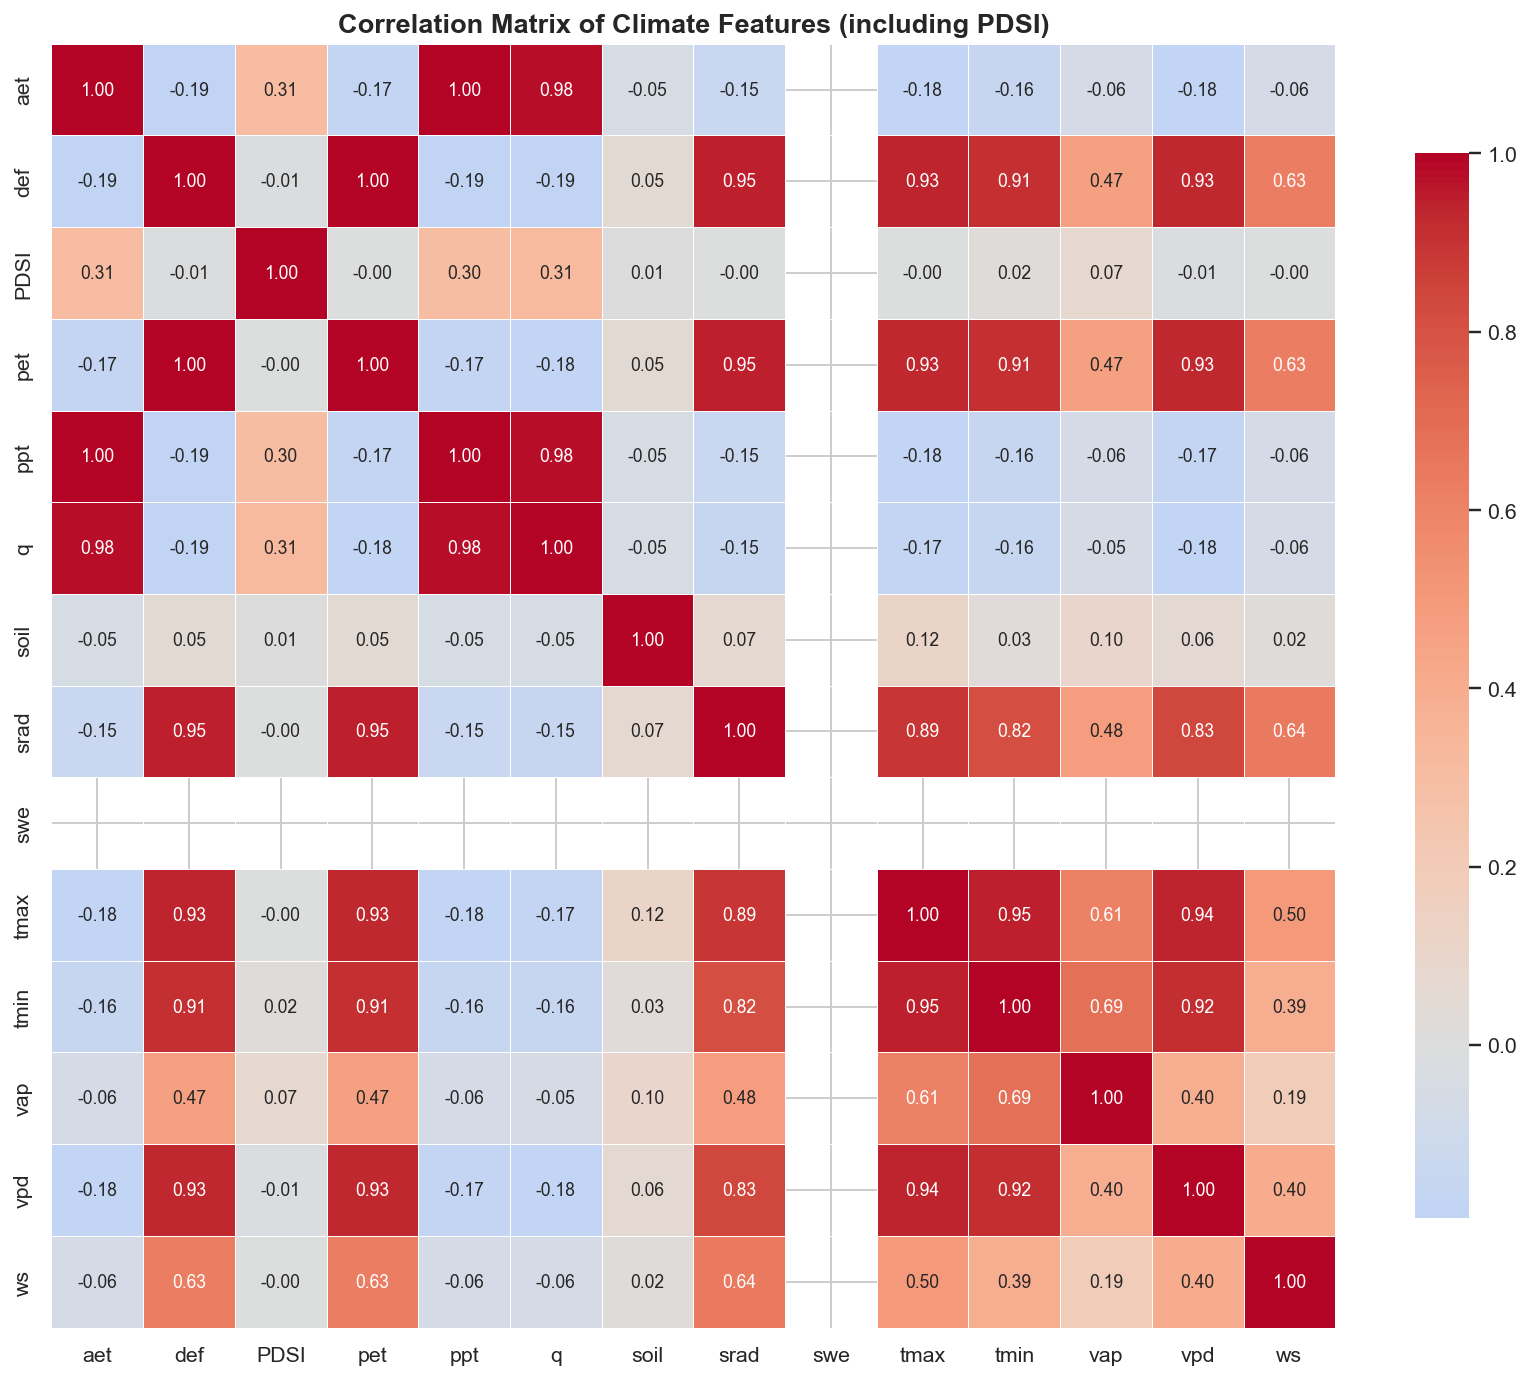

In [7]:
# --- Correlation Analysis: PDSI vs All Climate Features ---
import matplotlib.pyplot as plt
import seaborn as sns

data_flat = da_full.values.reshape(-1, da_full.shape[-1])
df_full = pd.DataFrame(data_flat, columns=da_full.feature.values)
df_clean = df_full.drop(columns=['governorate'], errors='ignore').dropna()

corr_matrix = df_clean.corr(method="pearson")

plt.figure(figsize=(12, 10), dpi=140)
sns.heatmap(
    corr_matrix, 
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",     
    center=0,            
    square=True,         
    linewidths=0.5,      
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9}
)

plt.title("Correlation Matrix of Climate Features (including PDSI)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Drop 'swe' from DataFrame and coordinates list (Snow Water Equivalent is 0 across Egypt)
df_full = df_full.drop(columns=['swe'], errors='ignore')
features = [f for f in features if f != 'swe']
print(f"Features after dropping 'swe': {features}")

Features after dropping 'swe': ['aet', 'def', 'PDSI', 'pet', 'ppt', 'q', 'soil', 'srad', 'tmax', 'tmin', 'vap', 'vpd', 'ws', 'governorate']


In [9]:
# --- Top 5 Features Impacting PDSI (Professional Table) ---
top_5_corr = corr_matrix['PDSI'].drop('PDSI').abs().nlargest(5)

df_table = pd.DataFrame({
    "Feature": top_5_corr.index,
    "Correlation": corr_matrix.loc[top_5_corr.index, 'PDSI'].values
})
df_table["Correlation"] = df_table["Correlation"].round(3)

print("Top 5 Features Impacting PDSI:")
print(df_table.to_string(index=False))

Top 5 Features Impacting PDSI:
Feature  Correlation
      q        0.315
    aet        0.306
    ppt        0.305
    vap        0.074
   tmin        0.017


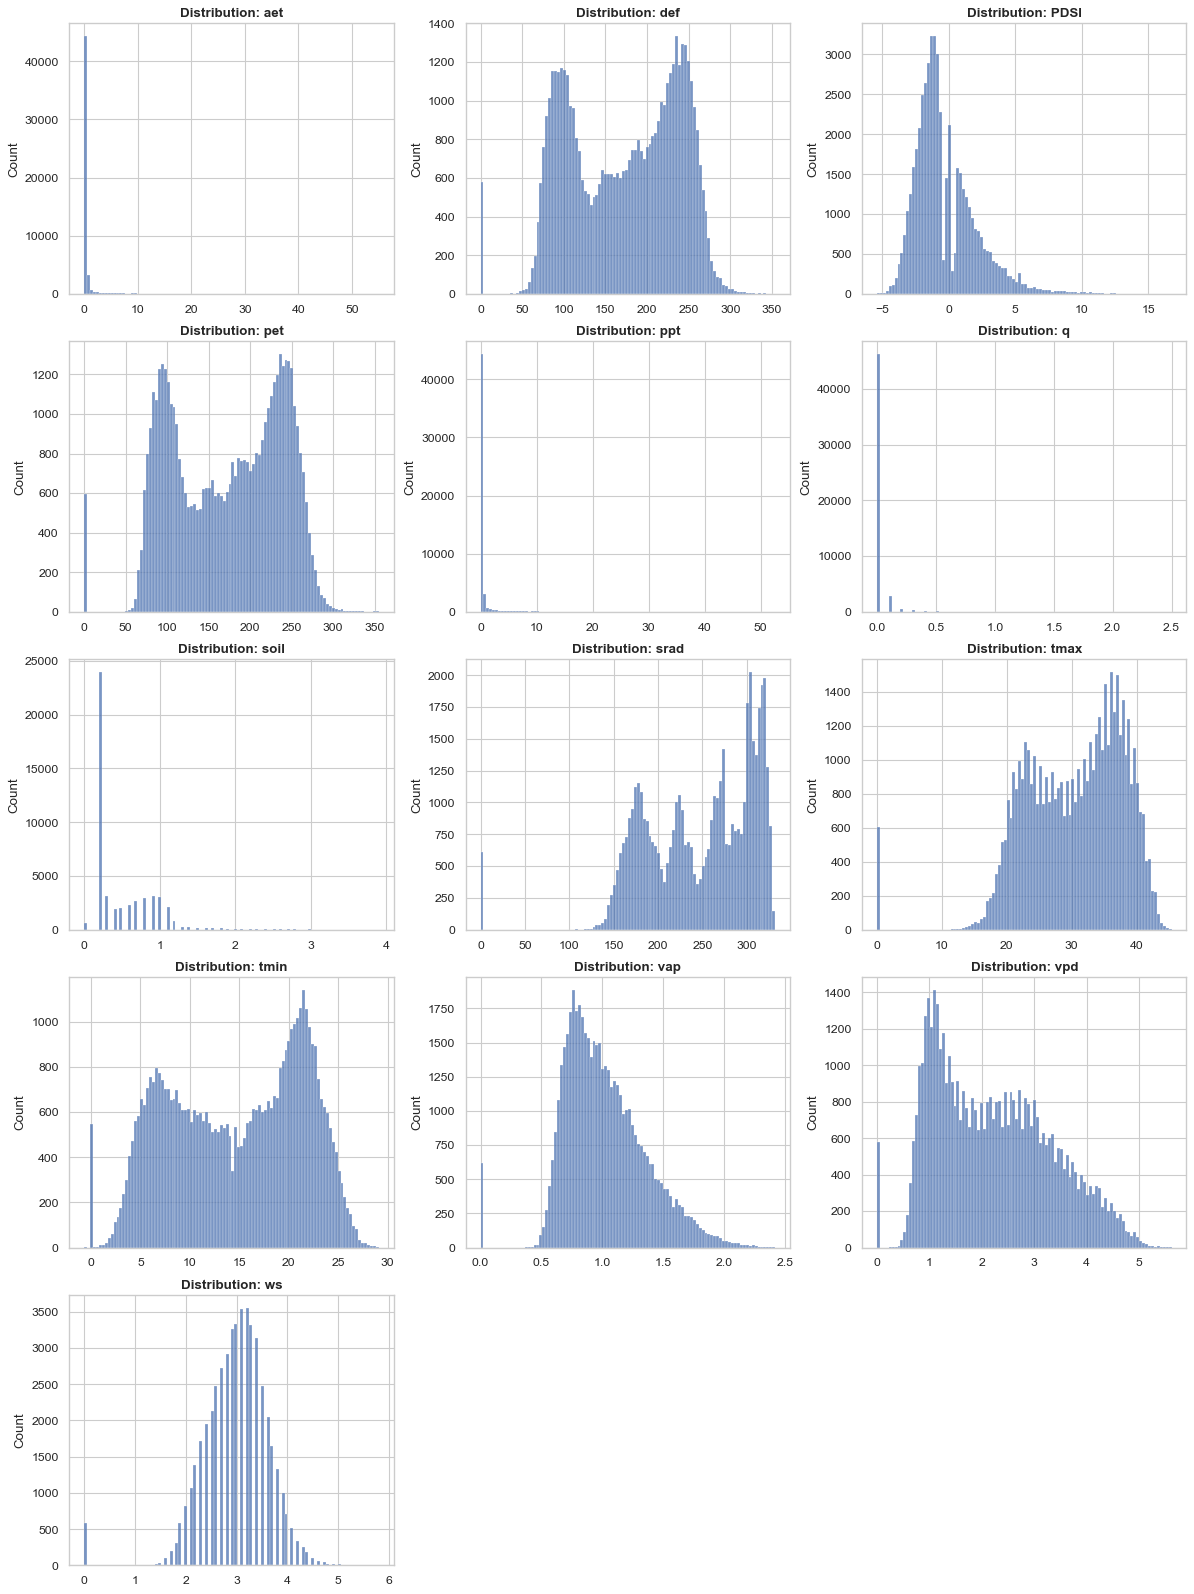

In [10]:
# --- Univariate Analysis: Standard Display ---
plot_features = [f for f in features if f != 'governorate']
n_feats = len(plot_features)
ncol = 3
nrow = int(np.ceil(n_feats / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(15, 4 * nrow), dpi=80)
axes = axes.flatten()

for i, feature in enumerate(plot_features):
    data_feat = da_full.sel(feature=feature).values.ravel()
    data_feat = data_feat[~np.isnan(data_feat)]
    
    if data_feat.size > 50000:
        data_feat = np.random.choice(data_feat, 50000, replace=False)
    
    sns.histplot(data_feat, ax=axes[i], kde=False, color="#4c72b0", edgecolor=None, bins=100)
    axes[i].set_title(f"Distribution: {feature}", fontweight="bold")

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [11]:
# Check if ppt and vpd features contain valid data or are all NaN
for f in ["ppt", "vpd"]:
    feat_data = tensor[..., features.index(f)]
    print(f"Analysis for feature '{f}':")
    print(f"  - Total elements: {feat_data.size}")
    print(f"  - Count of NaN values: {np.isnan(feat_data).sum()}")
    
    valid_data = feat_data[~np.isnan(feat_data)]
    if valid_data.size > 0:
        print(f"  - Unique values sample: {np.unique(valid_data[:10])}")
    else:
        print("  - Warning: This feature contains only NaN values.")


Analysis for feature 'ppt':
  - Total elements: 7962624
  - Count of NaN values: 0
  - Unique values sample: [0.6 0.7 0.8 1.2 1.3]
Analysis for feature 'vpd':
  - Total elements: 7962624
  - Count of NaN values: 0
  - Unique values sample: [0.732 0.734 0.736 0.737 0.757 0.773 0.786 0.795 0.818 0.819]


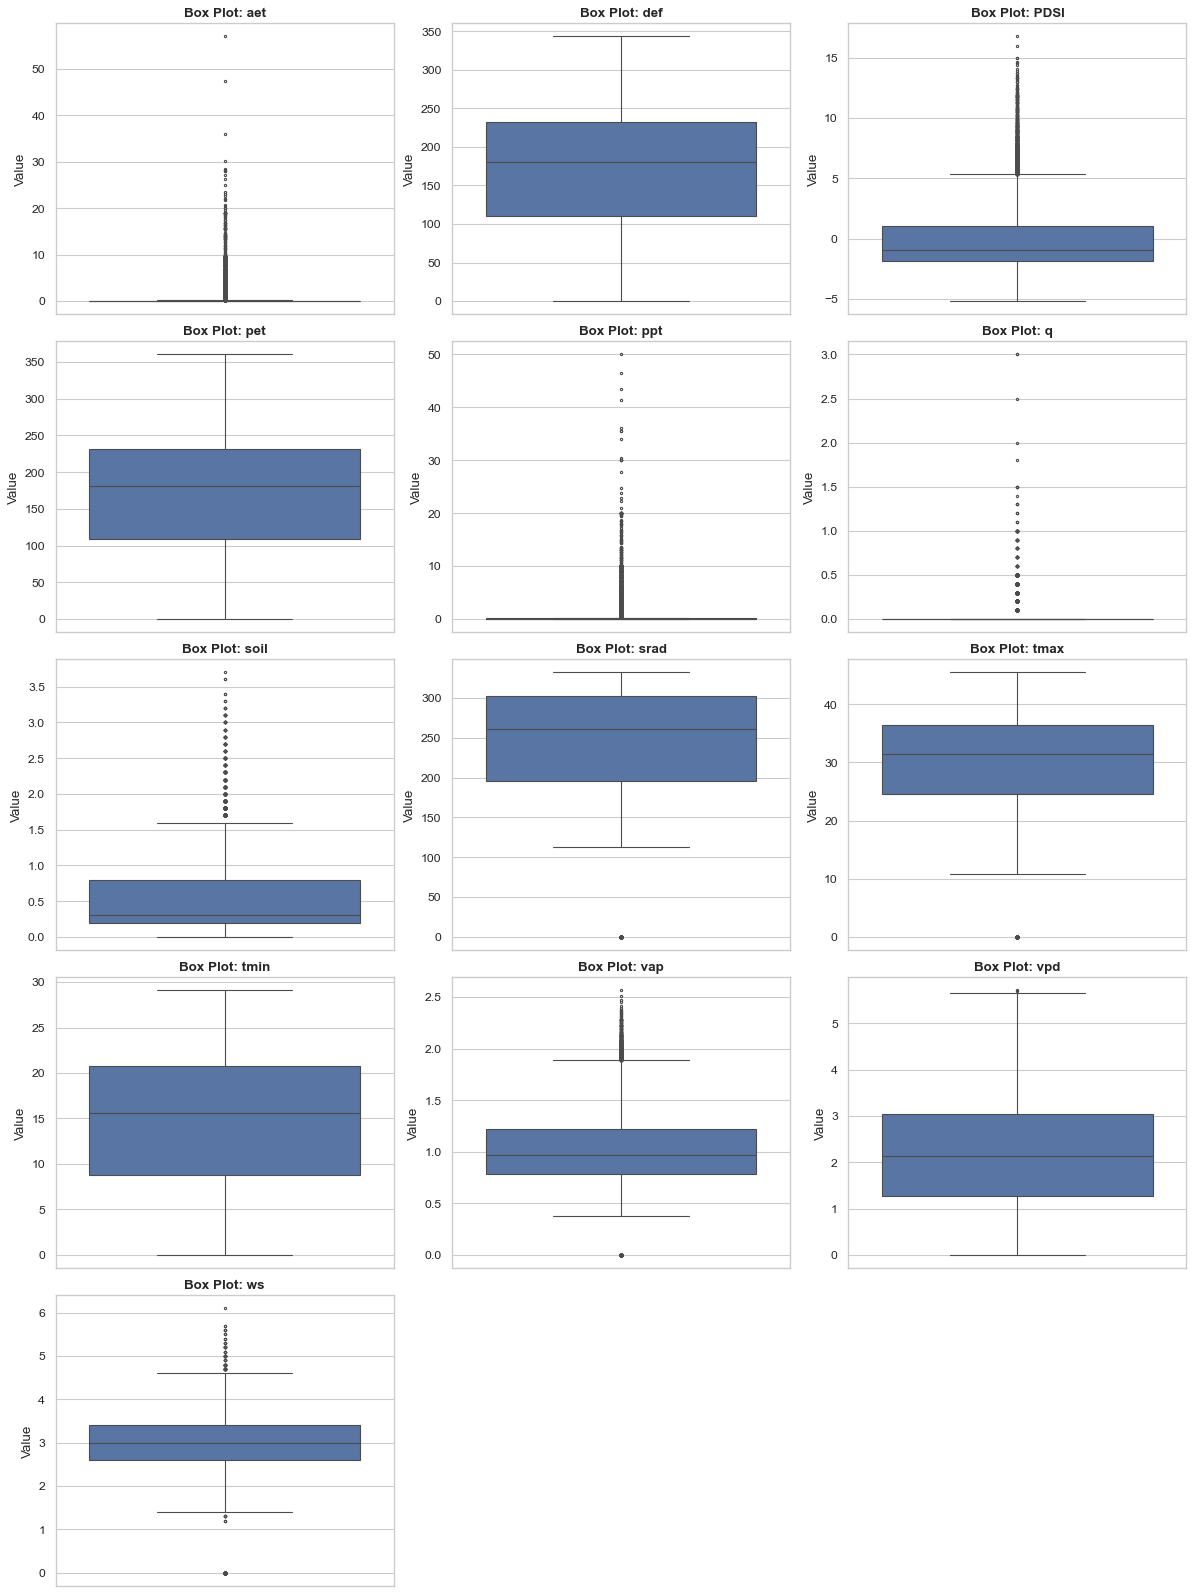

In [12]:
# --- Univariate Analysis: Box Plots for Climate Features ---
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 4 * nrow), dpi=80)
axes = axes.flatten()

for i, feature in enumerate(plot_features):
    data_feat = da_full.sel(feature=feature).values.ravel()
    data_feat = data_feat[~np.isnan(data_feat)]
    
    if data_feat.size > 50000:
        data_feat = np.random.choice(data_feat, 50000, replace=False)
    
    sns.boxplot(y=data_feat, ax=axes[i], color="#4c72b0", fliersize=2)
    axes[i].set_title(f"Box Plot: {feature}", fontweight="bold")
    axes[i].set_ylabel("Value")

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# Exclude swe and governorate from continuous statistics
stat_features = [f for f in features if f != 'swe' and f != 'governorate']

print("=" * 105)
print(f"  {'Feature':<8}  {'Mean':>9}  {'Median':>9}  {'Std':>9}  "
      f"{'Skew':>8}  {'Kurt':>8}  {'Min':>9}  {'Max':>9}")
print("-" * 105)

stat_rows = []
for name in stat_features:
    s = da_full.sel(feature=name).values.ravel()
    s = s[~np.isnan(s)]
    
    row = dict(
        Feature = name,
        Mean    = float(np.mean(s)),
        Median  = float(np.median(s)),
        Std     = float(np.std(s)),
        Skew    = float(skew(s)),
        Kurt    = float(kurtosis(s)),
        Min     = float(np.min(s)),
        Max     = float(np.max(s)),
    )
    stat_rows.append(row)
    skew_flag = "  HIGH SKEW" if abs(row["Skew"]) > 1.5 else ""
    
    print(f"  {name:<8}  {row['Mean']:>9.3f}  {row['Median']:>9.3f}  "
          f"{row['Std']:>9.3f}  {row['Skew']:>8.3f}  {row['Kurt']:>8.3f}  "
          f"{row['Min']:>9.3f}  {row['Max']:>9.3f}{skew_flag}")

print("=" * 105)
stats_df = pd.DataFrame(stat_rows).set_index("Feature")
print("stats_df is ready.")

  Feature        Mean     Median        Std      Skew      Kurt        Min        Max
---------------------------------------------------------------------------------------------------------
  aet           0.300      0.000      1.269    11.972   244.284      0.000     76.000  HIGH SKEW
  def         172.453    180.400     65.657    -0.230    -1.034      0.000    363.800
  PDSI         -0.256     -0.920      2.334     1.335     2.790     -5.690     19.630
  pet         172.753    180.600     65.423    -0.228    -1.032      0.000    363.900
  ppt           0.311      0.000      1.335    12.005   245.110      0.000     80.000  HIGH SKEW
  q             0.014      0.000      0.069    11.206   219.775      0.000      4.000  HIGH SKEW
  soil          0.494      0.300      0.395     1.617     4.130      0.000      3.900  HIGH SKEW
  srad        247.680    261.300     61.530    -0.866     1.188      0.000    332.200
  tmax         30.433     31.500      7.550    -0.807     1.345      0.000  

In [14]:
# Check the actual mean of every channel in the tensor
full_raw_channels = list(data["vars"]) + ["governorate"]

print("=" * 60)
print(f"  {'Index':<6} {'Channel Name':<16} {'Mean Value':>12}")
print("-" * 60)

for i in range(tensor.shape[-1]):
    channel_mean = np.nanmean(tensor[..., i])
    channel_name = full_raw_channels[i] if i < len(full_raw_channels) else f"Channel_{i}"
    print(f"  {i:<6} {channel_name:<16} {channel_mean:>12.3f}")

print("=" * 60)

  Index  Channel Name       Mean Value
------------------------------------------------------------
  0      aet                     0.300
  1      def                   172.453
  2      PDSI                   -0.256
  3      pet                   172.753
  4      ppt                     0.311
  5      q                       0.014
  6      soil                    0.494
  7      srad                  247.680
  8      tmax                    0.000
  9      tmin                   30.433
  10     vap                    14.765
  11     vpd                     1.025
  12     ws                      2.220
  13     governorate             2.990
  14     Channel_14              1.399


## Stage 2 — First-Order Differencing (d=1) & Stationarity per Governorate

> **Stationarity & Differencing Architecture:**  
> - **Overcoming Deceptive ADF (d=0)**: While PDSI is numerically stationary due to mean-reversion, strong lag-1 autocorrelation (rho > 0.85) creates a lazy persistence trap.  
> - **Enforced First-Differencing (d=1)**: We apply first-order differencing (Delta PDSI = PDSI(t) - PDSI(t-1)) across all governorate series to isolate short-term climate shocks and transition velocity.
> - **ACF/PACF on Differenced Series**: All autocorrelation analysis is performed directly on the d=1 differenced series.

In [15]:
import sys
try:
    import statsmodels
    print(f"Statsmodels version: {statsmodels.__version__}")
except ImportError:
    !{sys.executable} -m pip install statsmodels

Statsmodels version: 0.14.6


In [16]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np

def run_adf(series: pd.Series, label: str, alpha: float = 0.05) -> dict:
    """Run ADF test on series with safety checks."""
    clean = series.replace([np.inf, -np.inf], np.nan).dropna()
    if len(clean) < 15:
        return {"label": label, "p_value": 1.0, "is_stationary": False, "adf_stat": 0.0}
    try:
        result = adfuller(clean, autolag="AIC")
        stat, pval = result[0], result[1]
        return {
            "label": label,
            "adf_stat": stat,
            "p_value": pval,
            "is_stationary": (pval < alpha),
            "crit_1pct": result[4]["1%"],
            "crit_5pct": result[4]["5%"],
            "crit_10pct": result[4]["10%"],
        }
    except Exception:
        return {"label": label, "p_value": 1.0, "is_stationary": False, "adf_stat": 0.0}

def ensure_stationarity_enforced_diff(series: pd.Series, label: str, alpha: float = 0.05, force_d1: bool = True):
    """
    Compute stationarity report for d=0 and enforce first-order differencing (d=1)
    to break heavy autoregressive persistence.
    """
    clean_s = series.replace([np.inf, -np.inf], np.nan).dropna()
    res_d0 = run_adf(clean_s, label=f"{label} (d=0)", alpha=alpha)
    
    # Apply first-order differencing
    diff_s = clean_s.diff().dropna()
    res_d1 = run_adf(diff_s, label=f"{label} (d=1)", alpha=alpha)
    
    results = [res_d0, res_d1]
    final_series = diff_s if force_d1 else clean_s
    n_diffs = 1 if force_d1 else 0
    
    return final_series, n_diffs, results

print("Enforced first-order differencing ADF helpers defined.")

Enforced first-order differencing ADF helpers defined.


In [17]:
import sys
print(f"Python interpreter: {sys.executable}")

Python interpreter: d:\Climate_Project\py_gpu_env\Scripts\python.exe


In [18]:
def ensure_stationarity(series: pd.Series, label: str, alpha: float = 0.05, max_diff: int = 2):
    """Enforce d=1 first-order differencing to break lag-1 persistence."""
    return ensure_stationarity_enforced_diff(series, label, alpha, force_d1=True)

Dataset dimensions: ('time', 'lat', 'lon', 'feature')


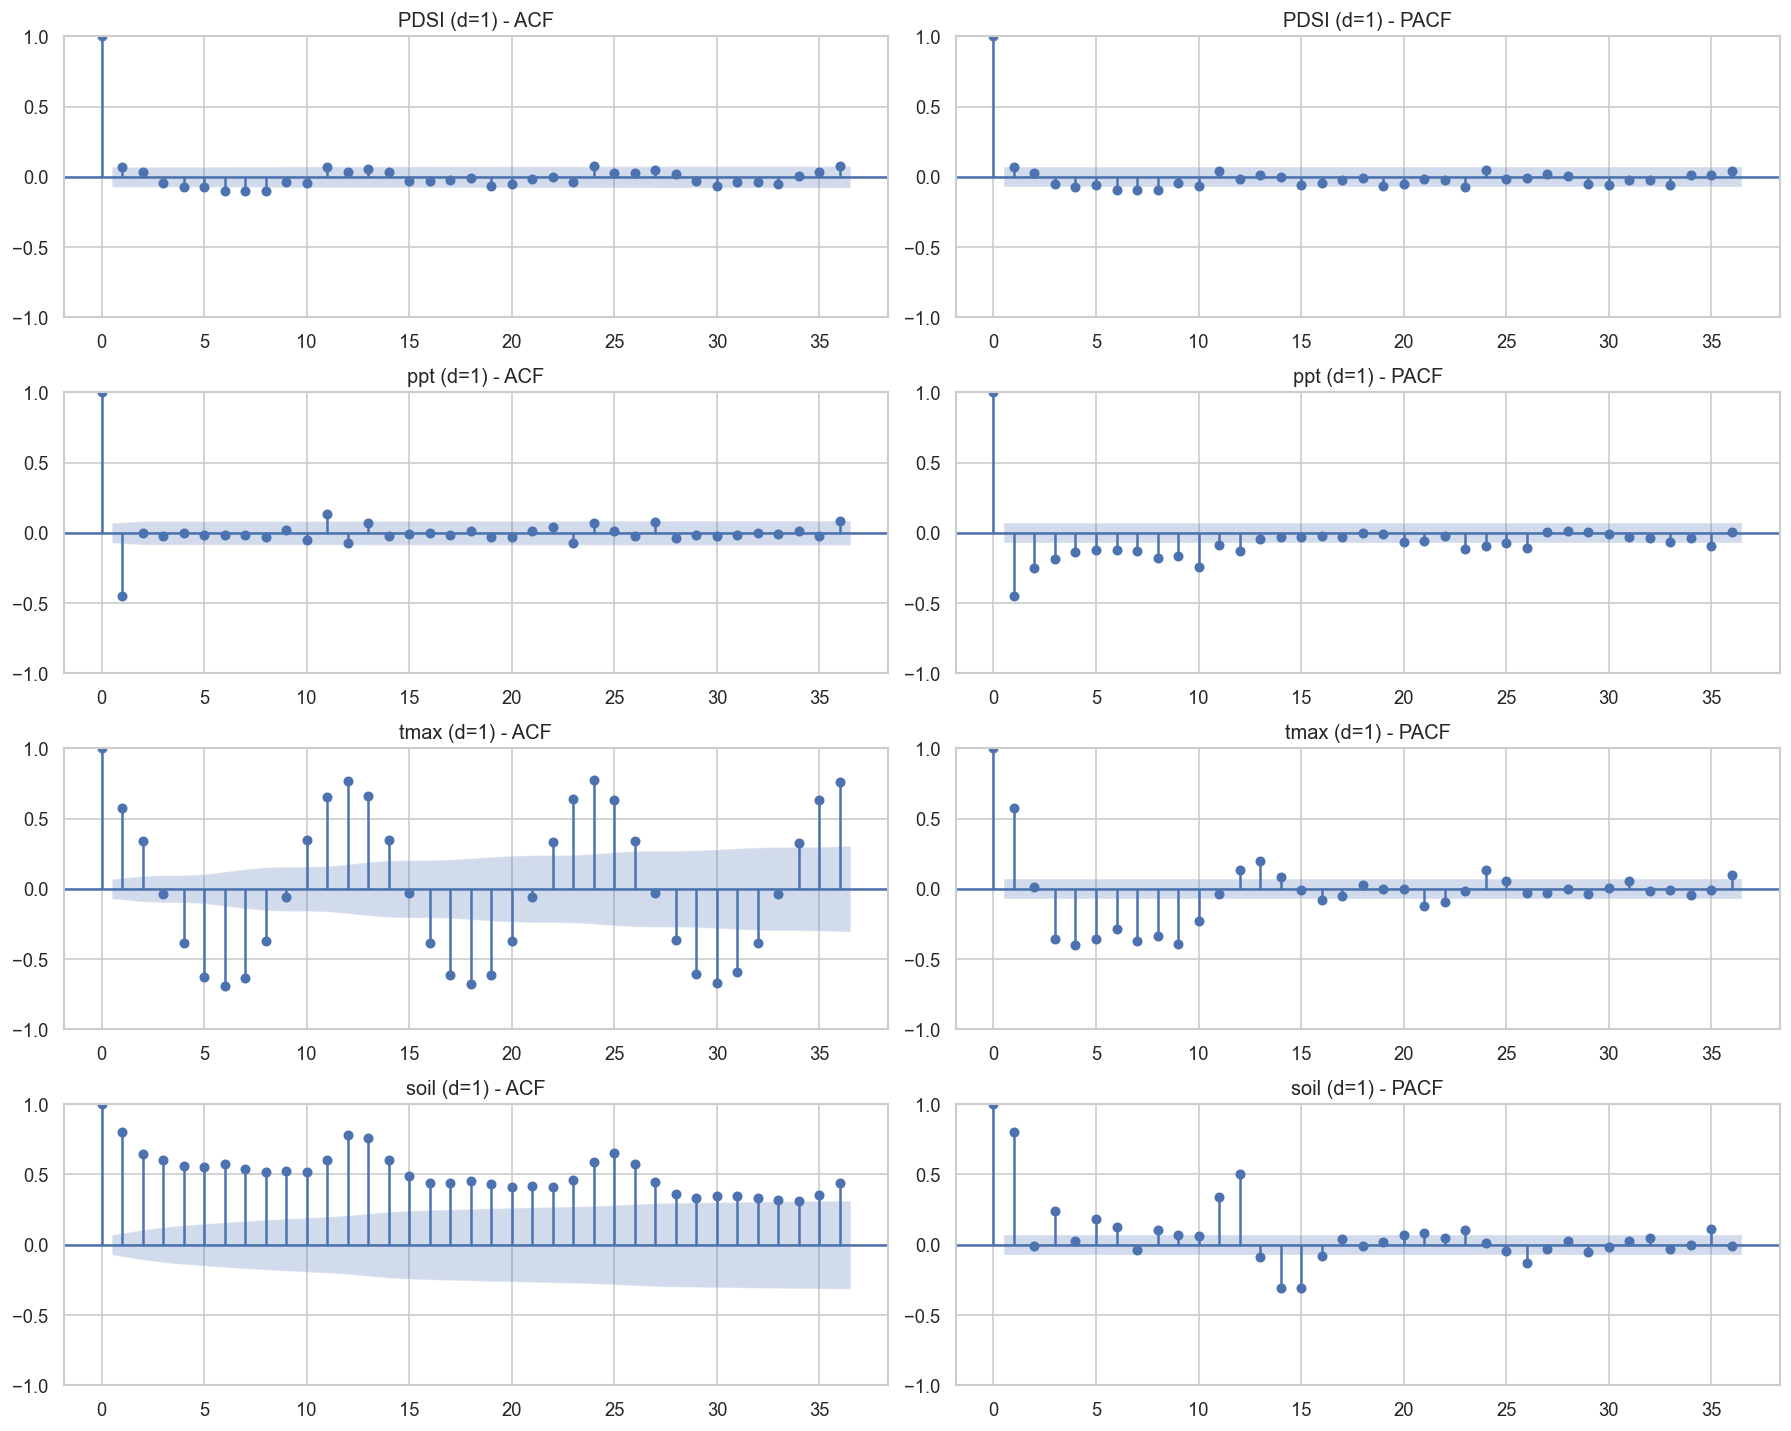

In [19]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print(f"Dataset dimensions: {da_full.dims}")
spatial_dims = [dim for dim in da_full.dims if dim in ['lat', 'lon', 'y', 'x']]

# Plot sample ACF and PACF for Differenced Climate Variables (d=1)
fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.flatten()

sample_feats = ['PDSI', 'ppt', 'tmax', 'soil']
for i, name in enumerate(sample_feats):
    data_slice = da_full.sel(feature=name)
    s_series = data_slice.mean(dim=spatial_dims).to_pandas().dropna()
    diff_series = s_series.diff().dropna()
    
    plot_acf(diff_series, lags=36, ax=axes[i*2], title=f"{name} (d=1) - ACF")
    plot_pacf(diff_series, lags=36, ax=axes[i*2+1], title=f"{name} (d=1) - PACF", method="ywm")

plt.tight_layout()
plt.show()

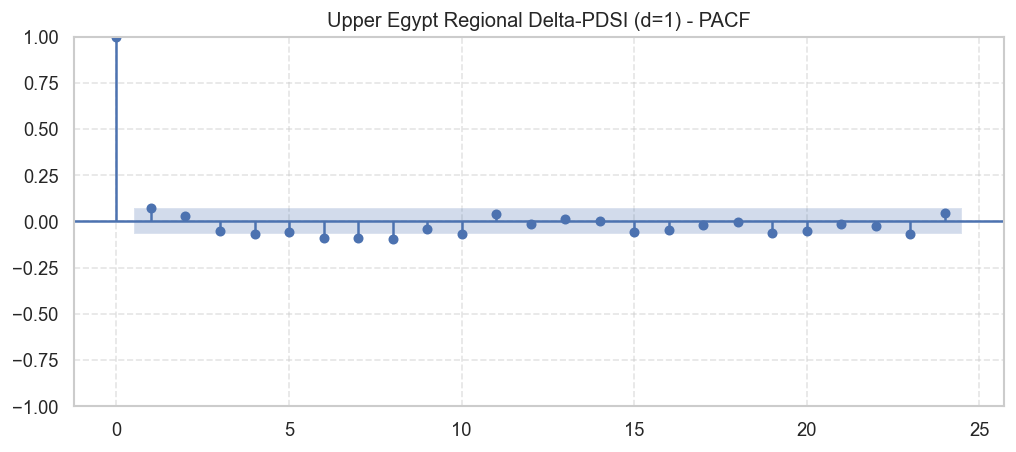

In [20]:
# Quick verification of PACF on Differenced Regional PDSI (d=1)
fig, ax = plt.subplots(figsize=(10, 4))
pdsi_series = da_full.sel(feature='PDSI').mean(dim=['lat', 'lon']).to_pandas().dropna()
diff_pdsi = pdsi_series.diff().dropna()
plot_pacf(diff_pdsi, lags=24, ax=ax, title="Upper Egypt Regional Delta-PDSI (d=1) - PACF", method="ywm")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [21]:
print("Available dimensions:", da_full.dims)
print("Available coordinates:", list(da_full.coords))

Available dimensions: ('time', 'lat', 'lon', 'feature')
Available coordinates: ['time', 'lat', 'lon', 'feature']


In [22]:
print("Feature coordinates:", da_full.coords['feature'].values)

Feature coordinates: ['aet' 'def' 'PDSI' 'pet' 'ppt' 'q' 'soil' 'srad' 'swe' 'tmax' 'tmin'
 'vap' 'vpd' 'ws' 'governorate']


In [23]:
# Check the exact data content for the 'governorate' feature
gov_data = da_full.sel(feature='governorate')
print(gov_data)

<xarray.DataArray 'NileGuard_Data' (time: 768, lat: 144, lon: 72)> Size: 32MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 4., 4., 0.],
        [0., 0., 0., ..., 4., 4., 0.],
        [0., 0., 0., ..., 0., 4., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 4., 4., 0.],
        [0., 0., 0., ..., 4., 4., 0.],
        [0., 0., 0., ..., 0., 4., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 4., 4., 0.],
        [0., 0., 0., ..., 4., 4., 0.],
        [0., 0., 0., ..., 0., 4., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 4.

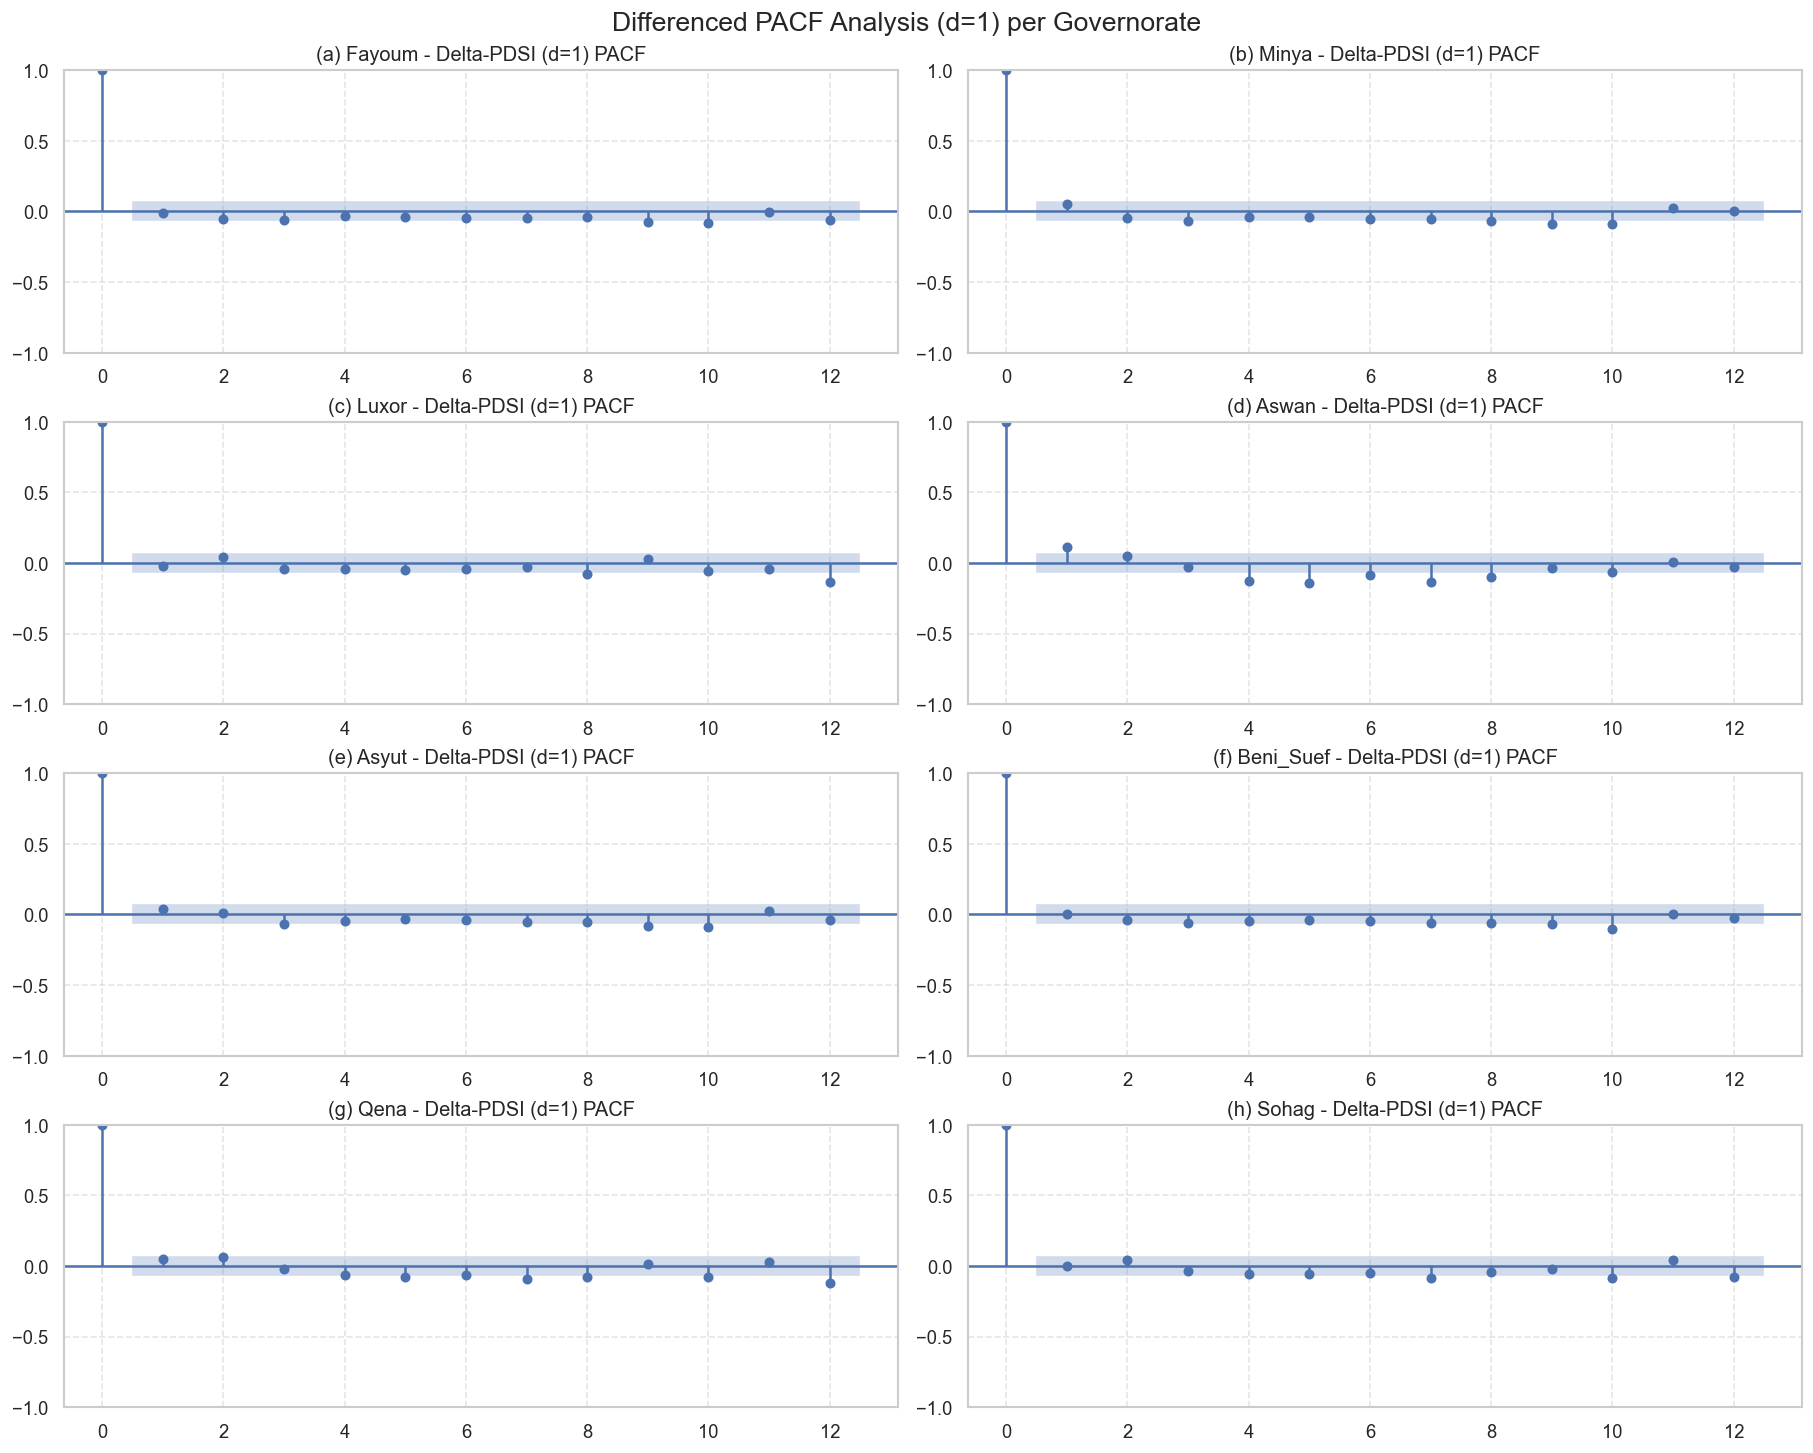

In [24]:
# --- PACF Analysis on Differenced PDSI (d=1) for Selected Governorates ---
# Using standardized config.gov_map for true spatial alignment
gov_mask_slice = da_full.sel(feature='governorate')
unique_govs = np.unique(gov_mask_slice.values)
unique_govs = unique_govs[unique_govs > 0]
fig, axes = plt.subplots(4, 2, figsize=(15, 12), constrained_layout=True)
axes = axes.flatten()
for i in range(min(8, len(unique_govs))):
    gov_id = unique_govs[i]
    ax = axes[i]
    
    current_gov_mask = (gov_mask_slice == gov_id)
    data_slice = da_full.sel(feature='PDSI').where(current_gov_mask)
    series = data_slice.mean(dim=['lat', 'lon']).to_pandas().dropna()
    diff_s = series.diff().dropna()
    
    plot_pacf(diff_s, lags=12, ax=ax, method='yw')
    title_label = config.gov_map.get(int(gov_id), f'Gov_{int(gov_id)}')
    ax.set_title(f"({chr(97+i)}) {title_label} - Delta-PDSI (d=1) PACF")
    ax.grid(True, linestyle='--', alpha=0.5)
plt.suptitle('Differenced PACF Analysis (d=1) per Governorate', fontsize=16)
plt.show()


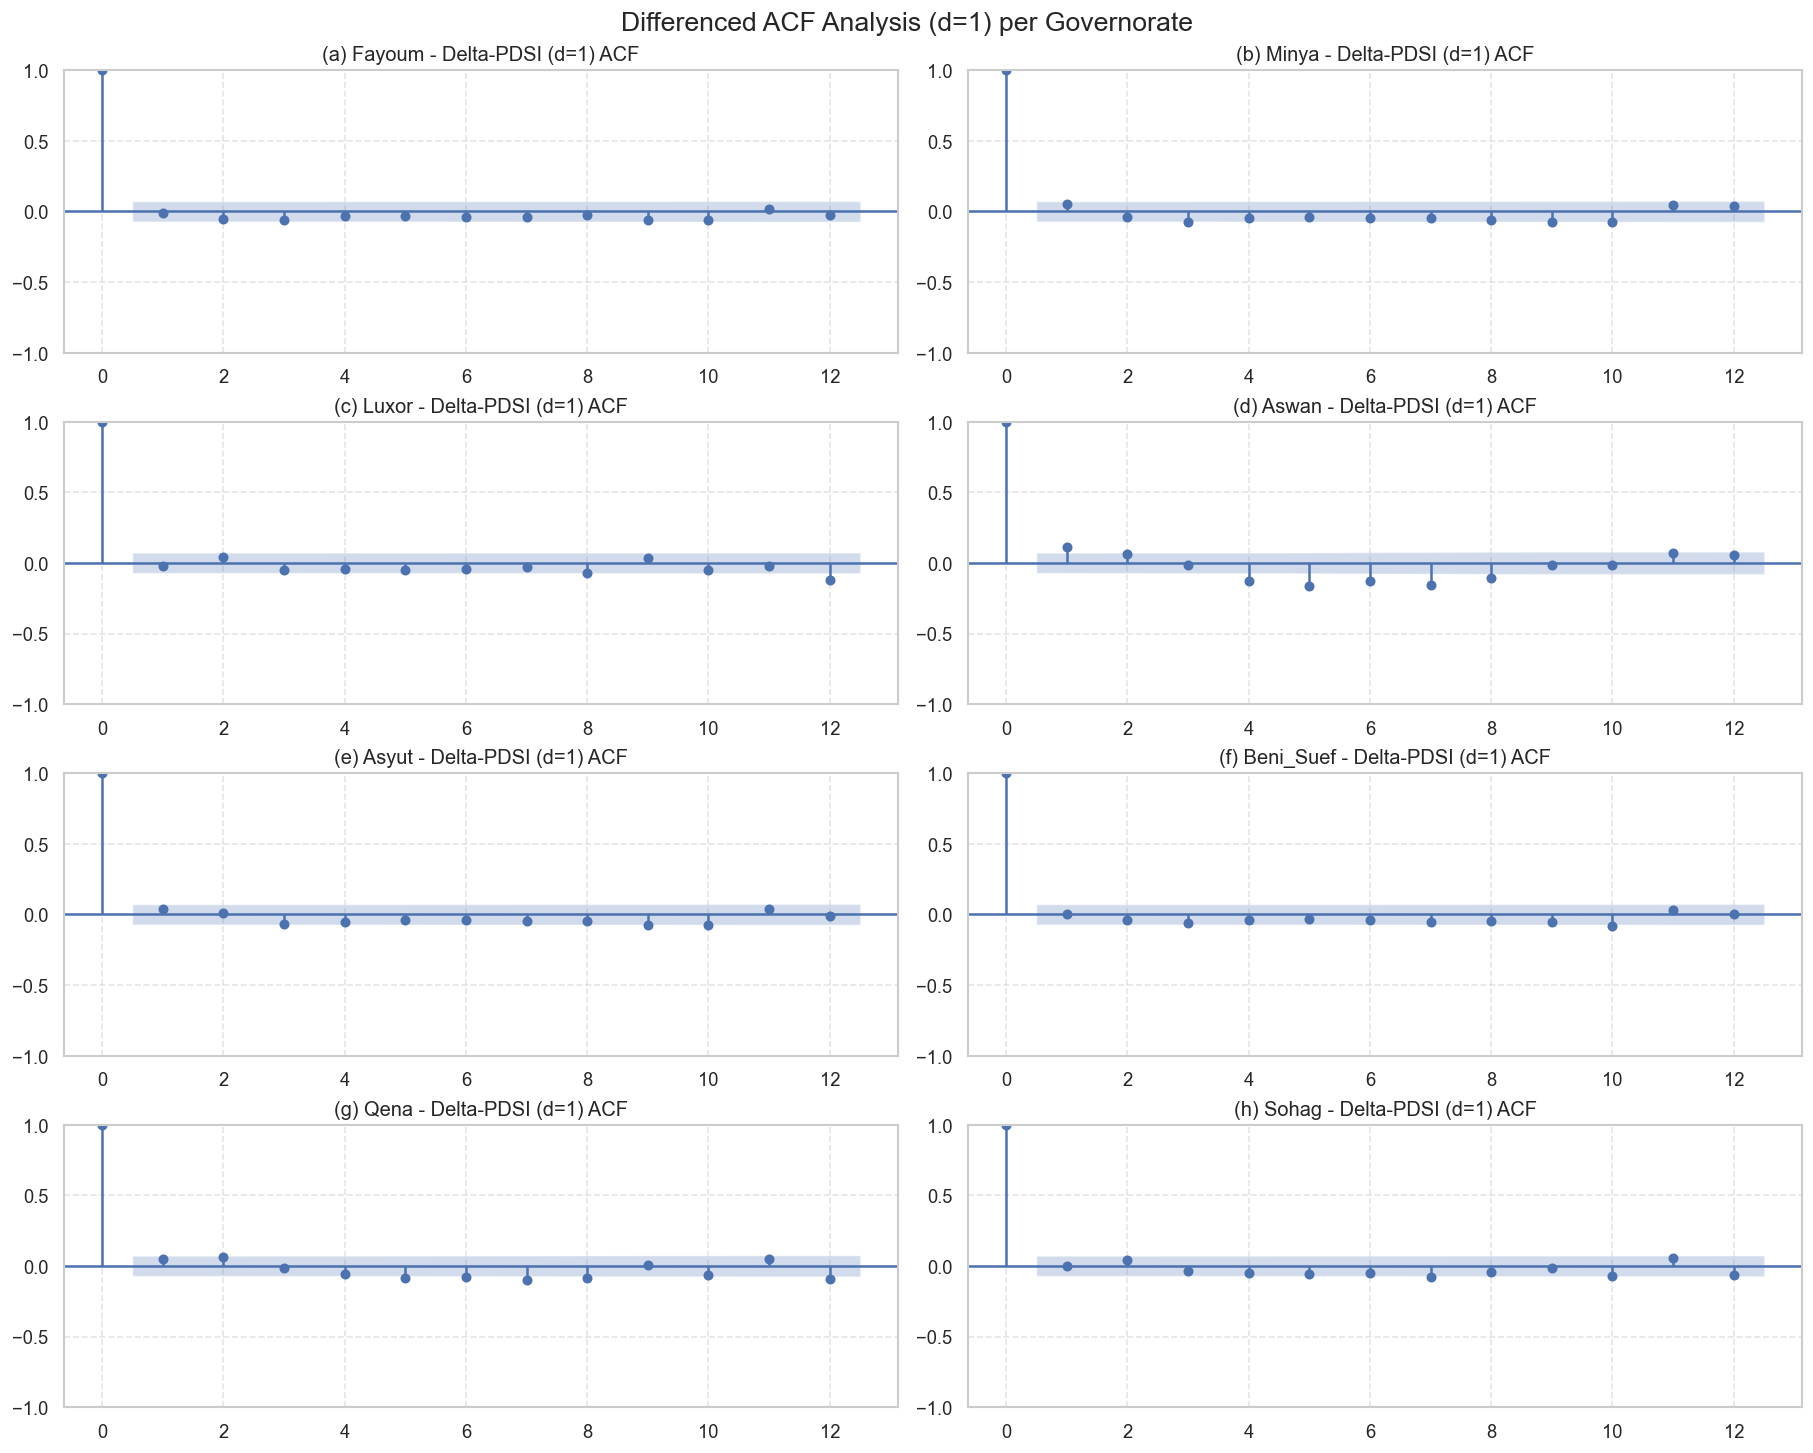

In [25]:
# --- ACF Analysis on Differenced PDSI (d=1) for Selected Governorates ---
fig, axes = plt.subplots(4, 2, figsize=(15, 12), constrained_layout=True)
axes = axes.flatten()
for i in range(min(8, len(unique_govs))):
    gov_id = unique_govs[i]
    ax = axes[i]
    
    current_gov_mask = (gov_mask_slice == gov_id)
    data_slice = da_full.sel(feature='PDSI').where(current_gov_mask)
    series = data_slice.mean(dim=['lat', 'lon']).to_pandas().dropna()
    diff_s = series.diff().dropna()
    
    plot_acf(diff_s, lags=12, ax=ax)
    title_label = config.gov_map.get(int(gov_id), f'Gov_{int(gov_id)}')
    ax.set_title(f"({chr(97+i)}) {title_label} - Delta-PDSI (d=1) ACF")
    ax.grid(True, linestyle='--', alpha=0.5)
plt.suptitle('Differenced ACF Analysis (d=1) per Governorate', fontsize=16)
plt.show()


In [26]:
# ============================================================
# Run Enforced Stationarity & Differencing Tests (PDSI)
# ============================================================
adf_summary = {}
differenced_series = {}
raw_series_dict = {}
print("=" * 80)
print(f"  {'Governorate':<20} {'Stage':<8} {'ADF Stat':>12} {'p-value':>12} {'Status'}")
print("-" * 80)
for i, gov_id in enumerate(unique_govs):
    gov_name = config.gov_map.get(int(gov_id), f'Gov_{int(gov_id)}')
    current_gov_mask = (gov_mask_slice == gov_id)
    raw_s = da_full.sel(feature='PDSI').where(current_gov_mask).mean(dim=['lat', 'lon']).to_pandas().dropna()
    
    final_s, n_diffs, results = ensure_stationarity_enforced_diff(raw_s, label=gov_name, force_d1=True)
    adf_summary[gov_name] = {"n_diffs": n_diffs, "final_series": final_s, "results": results}
    differenced_series[gov_name] = final_s
    raw_series_dict[gov_name] = raw_s
    
    for res in results:
        status_label = "STATIONARY" if res["is_stationary"] else "NON-STATIONARY"
        print(f"  {gov_name:<20} {res['label']:<8} {res['adf_stat']:>12.4f} {res['p_value']:>12.6f} {status_label}")
print("=" * 80)


  Governorate          Stage        ADF Stat      p-value Status
--------------------------------------------------------------------------------
  Fayoum               Fayoum (d=0)      -6.3386     0.000000 STATIONARY
  Fayoum               Fayoum (d=1)     -11.5997     0.000000 STATIONARY
  Minya                Minya (d=0)      -6.6485     0.000000 STATIONARY
  Minya                Minya (d=1)     -12.0034     0.000000 STATIONARY
  Luxor                Luxor (d=0)      -7.3108     0.000000 STATIONARY
  Luxor                Luxor (d=1)     -11.0070     0.000000 STATIONARY
  Aswan                Aswan (d=0)      -4.0894     0.001008 STATIONARY
  Aswan                Aswan (d=1)     -14.3489     0.000000 STATIONARY
  Asyut                Asyut (d=0)      -6.8554     0.000000 STATIONARY
  Asyut                Asyut (d=1)     -11.7171     0.000000 STATIONARY
  Beni_Suef            Beni_Suef (d=0)      -6.5582     0.000000 STATIONARY
  Beni_Suef            Beni_Suef (d=1)     -11.9644     

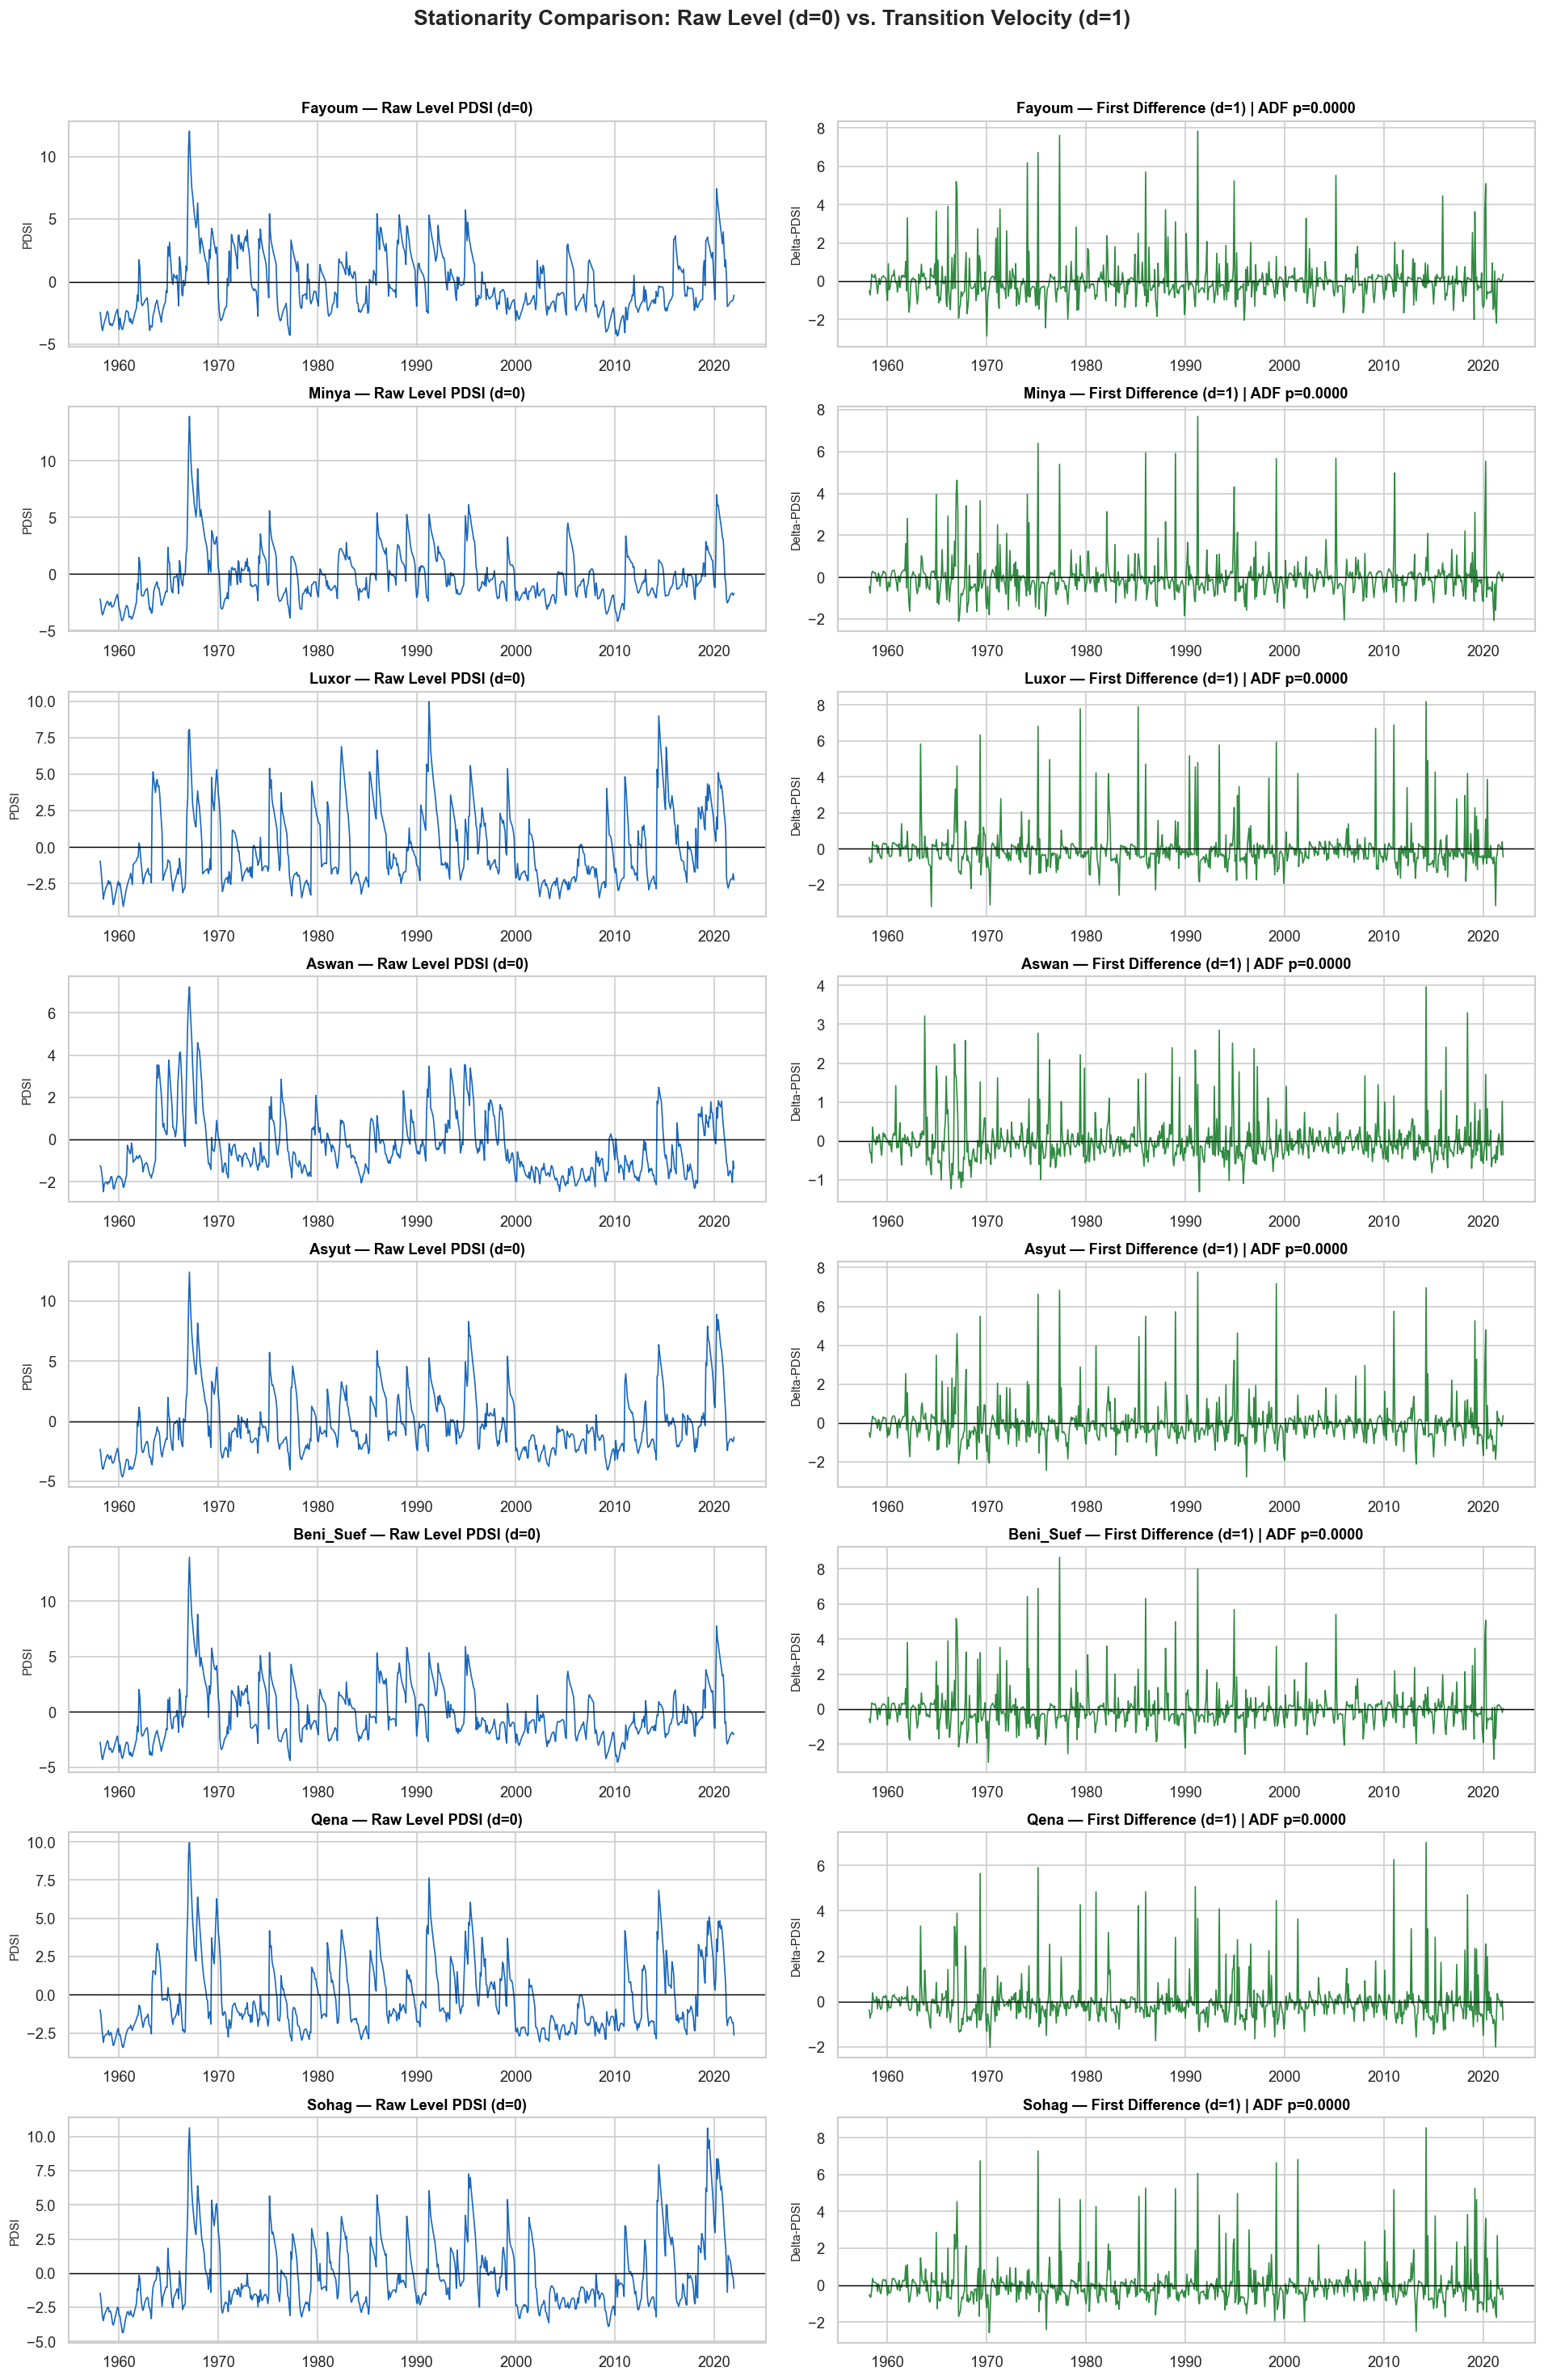

In [27]:
# --- Stationarity Visualization: Raw Level vs First Difference (d=1) ---
ACCENT = "#0056b3"
GREEN  = "#1a7d2d"

gov_names = list(differenced_series.keys())
N_GOV = len(gov_names)
fig, axes = plt.subplots(N_GOV, 2, figsize=(16, 3.0 * N_GOV))

for row_idx, gov_name in enumerate(gov_names):
    raw_s = raw_series_dict[gov_name]
    diff_s = differenced_series[gov_name]

    # Raw PDSI level
    ax_raw = axes[row_idx, 0]
    ax_raw.plot(raw_s.index, raw_s.values, color=ACCENT, lw=1, alpha=0.9)
    ax_raw.axhline(0, color="black", lw=0.8)
    ax_raw.set_title(f"{gov_name} — Raw Level PDSI (d=0)", color="black", fontsize=11, fontweight="bold")
    ax_raw.set_ylabel("PDSI", fontsize=9)

    # First difference (d=1)
    ax_st = axes[row_idx, 1]
    ax_st.plot(diff_s.index, diff_s.values, color=GREEN, lw=1, alpha=0.9)
    ax_st.axhline(0, color="black", lw=0.8)
    info = adf_summary[gov_name]["results"][1] # d=1 results
    ax_st.set_title(f"{gov_name} — First Difference (d=1) | ADF p={info['p_value']:.4f}", color="black", fontsize=11, fontweight="bold")
    ax_st.set_ylabel("Delta-PDSI", fontsize=9)

fig.suptitle("Stationarity Comparison: Raw Level (d=0) vs. Transition Velocity (d=1)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

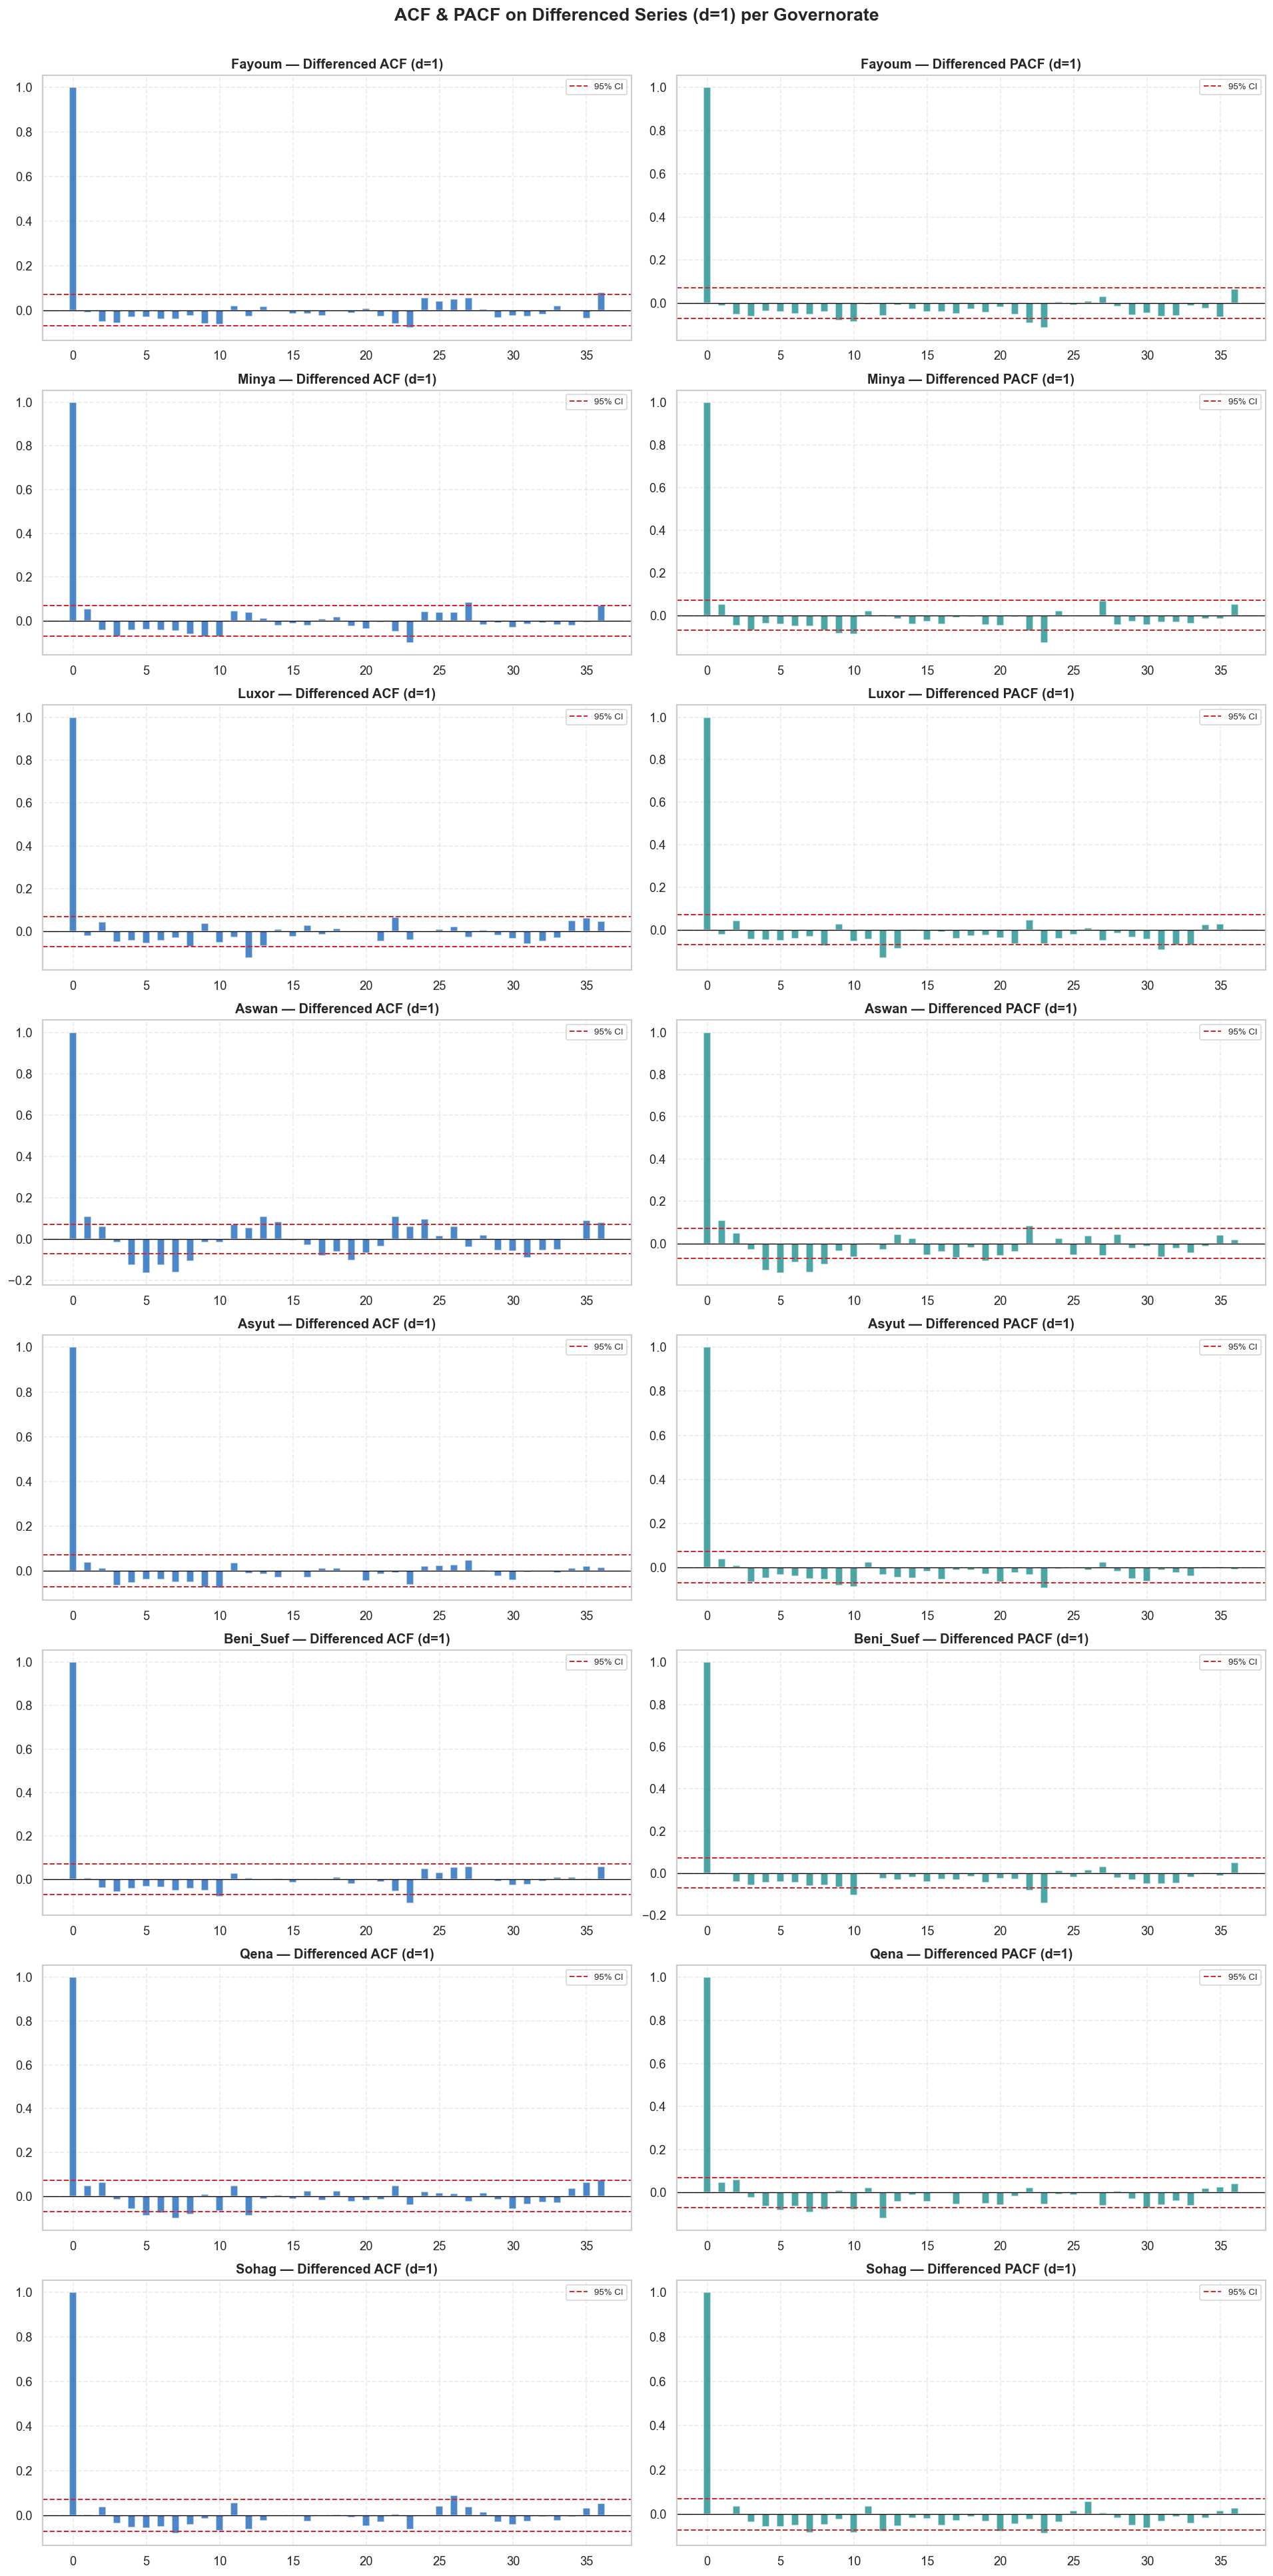

In [28]:
# --- High-Contrast ACF & PACF on Differenced Series (d=1) ---
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf

MAX_LAGS = 36
fig, axes = plt.subplots(N_GOV, 2, figsize=(16, 4.0 * N_GOV))

for row_idx, (gov_name, series) in enumerate(differenced_series.items()):
    s = series.dropna().values
    n_obs = len(s)
    ci_band = 1.96 / np.sqrt(n_obs)

    lags_arr = np.arange(MAX_LAGS + 1)
    acf_vals = acf(s, nlags=MAX_LAGS, fft=True)[0:MAX_LAGS+1]
    pacf_vals = pacf(s, nlags=MAX_LAGS, method="ywm")[0:MAX_LAGS+1]

    # ACF Plot
    ax_acf = axes[row_idx, 0]
    ax_acf.bar(lags_arr, acf_vals, color="#0056b3", alpha=0.7, width=0.5)
    ax_acf.axhline(ci_band, color="#d62728", lw=1.2, ls="--", label="95% CI")
    ax_acf.axhline(-ci_band, color="#d62728", lw=1.2, ls="--")
    ax_acf.axhline(0, color="black", lw=0.8)
    ax_acf.set_title(f"{gov_name} — Differenced ACF (d=1)", fontweight="bold")
    ax_acf.legend(loc="upper right", fontsize=8)
    ax_acf.grid(True, linestyle='--', alpha=0.4)

    # PACF Plot
    ax_pac = axes[row_idx, 1]
    ax_pac.bar(lags_arr, pacf_vals, color="#008080", alpha=0.7, width=0.5)
    ax_pac.axhline(ci_band, color="#d62728", lw=1.2, ls="--", label="95% CI")
    ax_pac.axhline(-ci_band, color="#d62728", lw=1.2, ls="--")
    ax_pac.axhline(0, color="black", lw=0.8)
    ax_pac.set_title(f"{gov_name} — Differenced PACF (d=1)", fontweight="bold")
    ax_pac.legend(loc="upper right", fontsize=8)
    ax_pac.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("ACF & PACF on Differenced Series (d=1) per Governorate", fontsize=16, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()

In [29]:
# --- ARIMA Grid Search on Differenced Series (d=1) ---
import itertools
from statsmodels.tsa.arima.model import ARIMA

def find_best_arima_order(series, p_range=range(0, 4), q_range=range(0, 4)):
    best_aic = float("inf")
    best_order = (1, 1, 1)
    for p, q in itertools.product(p_range, q_range):
        try:
            # Explicitly modeling with d=1 differencing order
            model = ARIMA(series, order=(p, 1, q)).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_order = (p, 1, q)
        except Exception:
            continue
    return best_order, best_aic

best_orders = {}
print(f"{'Governorate':<18} {'Best Order (p,d=1,q)':<22} {'AIC':<10}")
print("-" * 55)
for gov_name, s in raw_series_dict.items():
    order, aic = find_best_arima_order(s)
    best_orders[gov_name] = order
    print(f"{gov_name:<18} {str(order):<22} {aic:.2f}")

Governorate        Best Order (p,d=1,q)   AIC       
-------------------------------------------------------


d:\Climate_Project\py_gpu_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fayoum             (2, 1, 1)              2263.18


d:\Climate_Project\py_gpu_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Minya              (2, 1, 1)              2162.92


...

d:\Climate_Project\py_gpu_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Climate_Project\py_gpu_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Climate_Project\py_gpu_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Beni_Suef          (1, 1, 2)              2338.29


d:\Climate_Project\py_gpu_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Climate_Project\py_gpu_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Climate_Project\py_gpu_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Climate_Project\py_gpu_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Climate_Project\py_gpu_env\lib\site-packages\statsmodels\base\model.py:607: C

Qena               (3, 1, 1)              2102.89
Sohag              (3, 1, 1)              2354.02


d:\Climate_Project\py_gpu_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Governorate        Out-of-Sample RMSE     Out-of-Sample R2  
------------------------------------------------------------
Fayoum             3.2077                 -0.8463           
Minya              2.0825                 0.0175            
Luxor              2.4749                 -0.1400           
Aswan              1.3911                 -0.2225           
Asyut              3.3430                 -0.2127           
Beni_Suef          2.8105                 -0.4737           


d:\Climate_Project\py_gpu_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Qena               2.4967                 -0.1630           
Sohag              4.0977                 -0.4412           


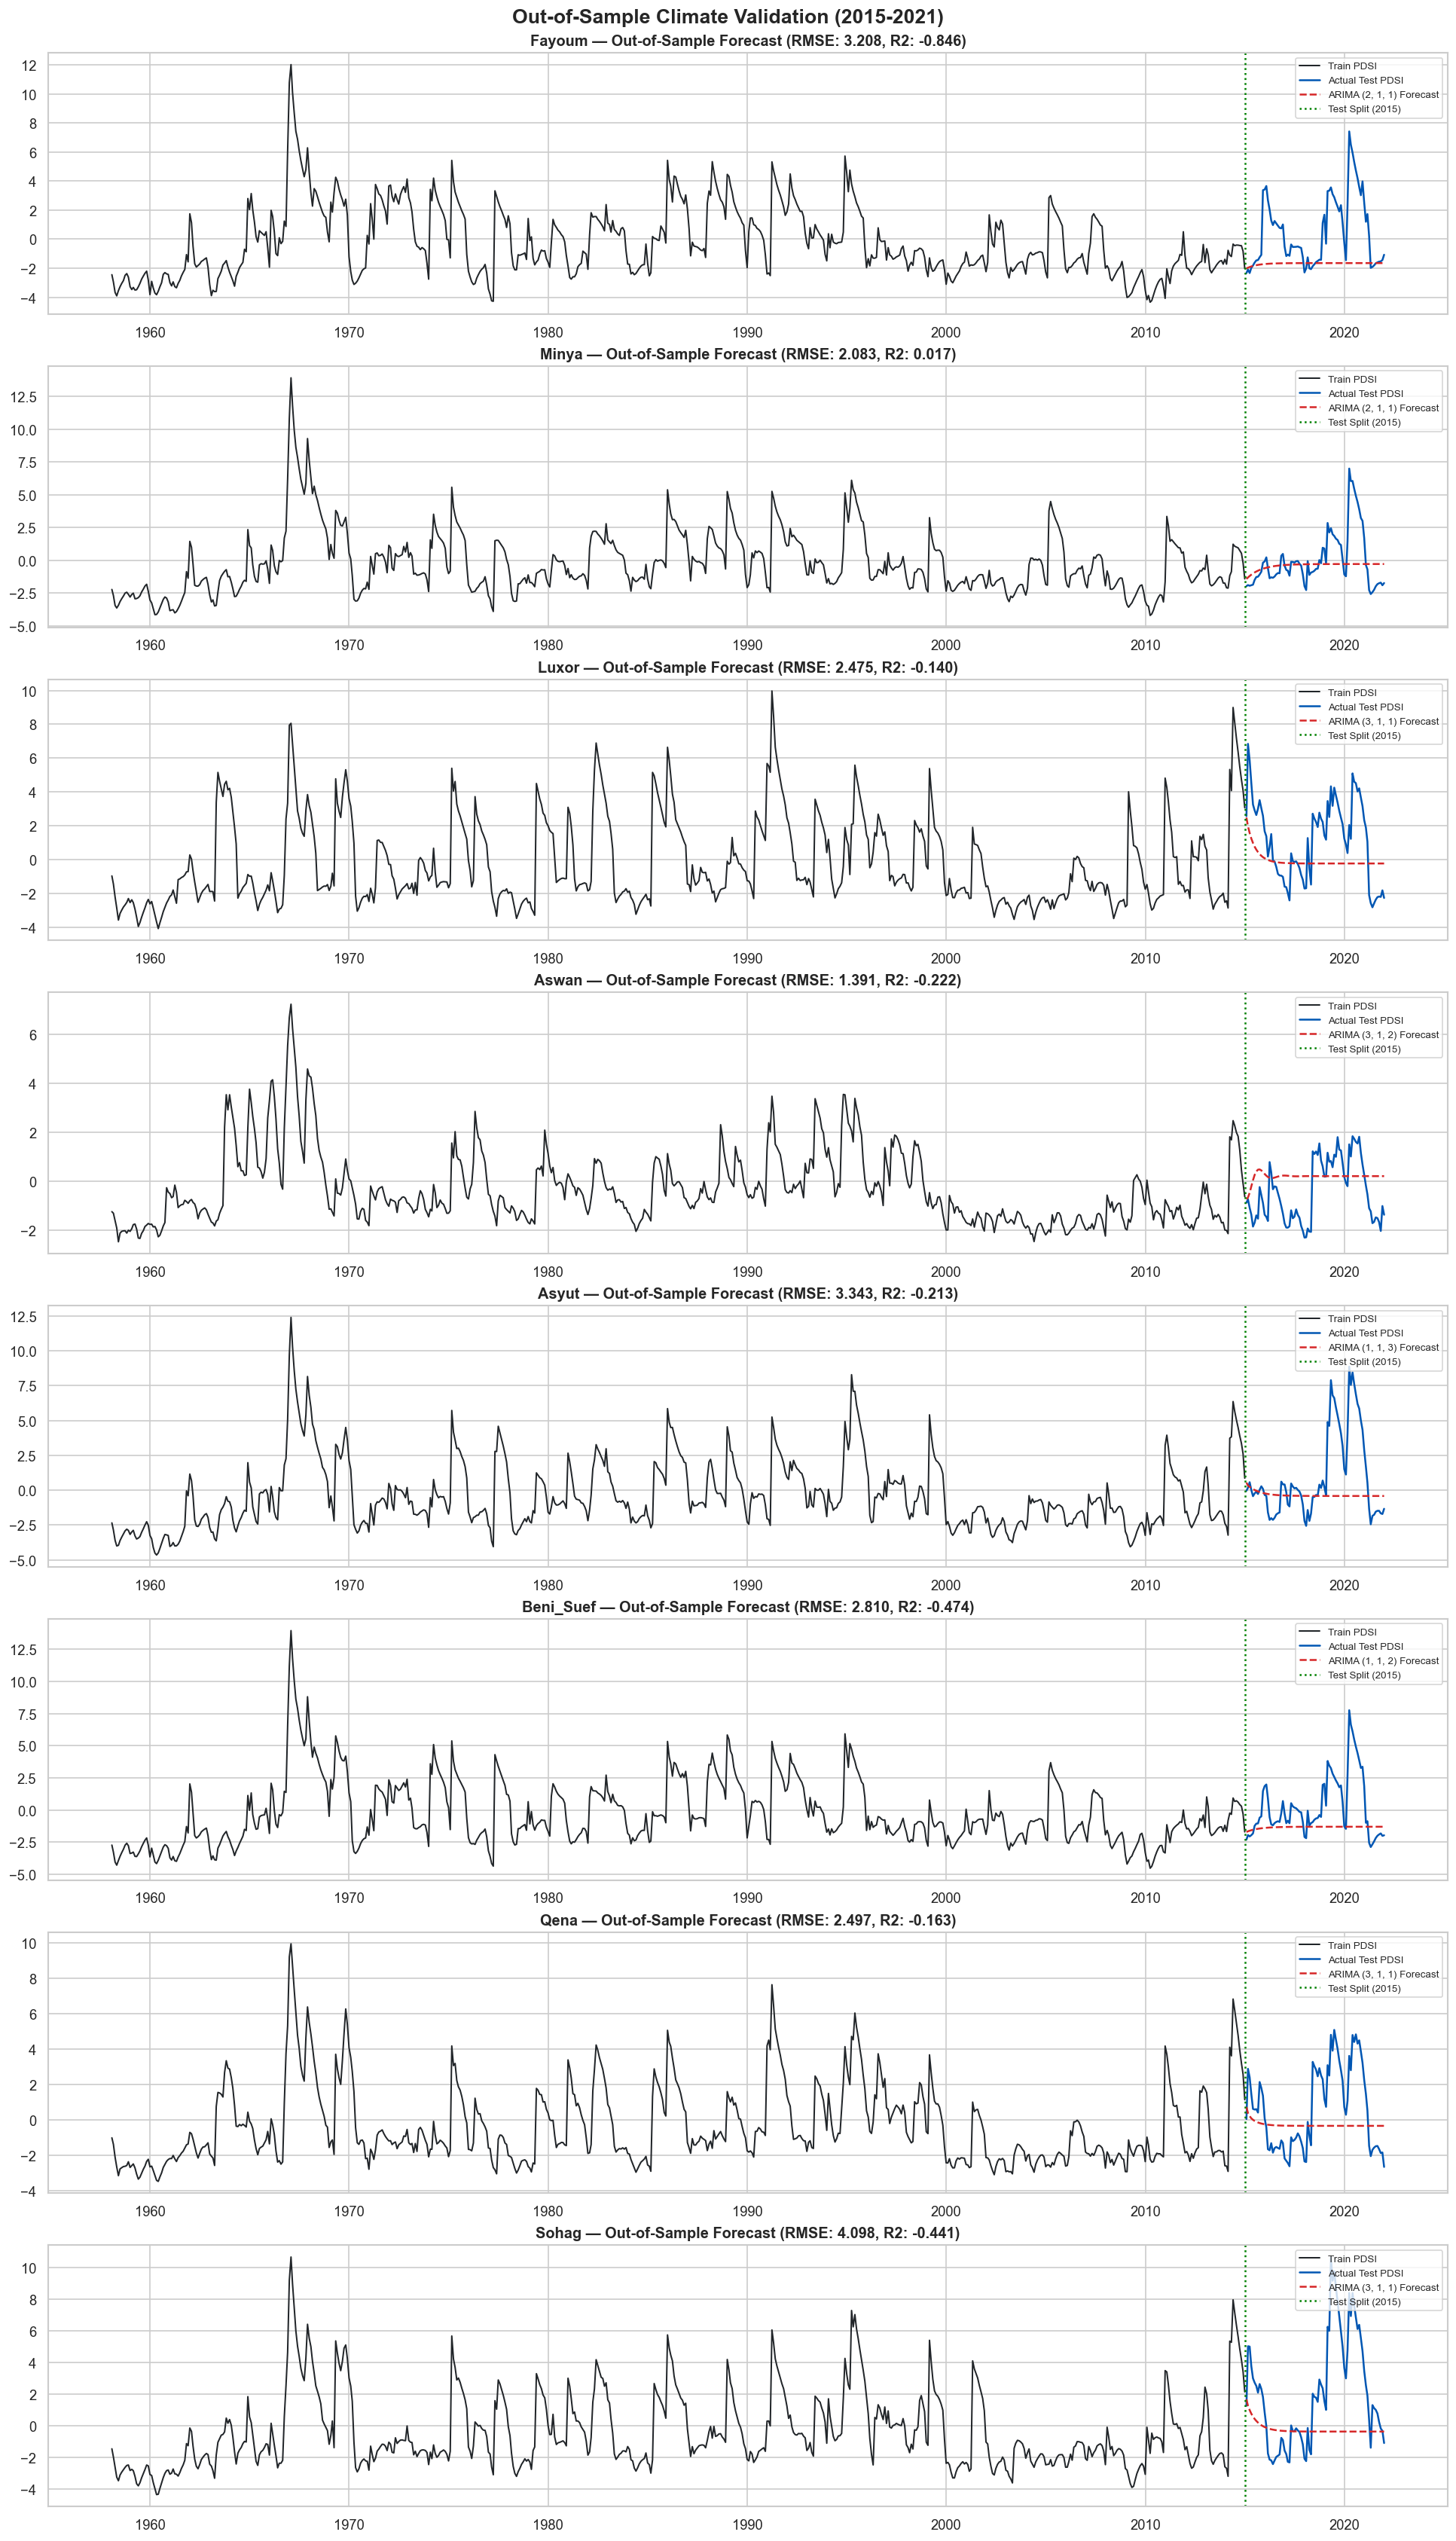

In [30]:
# --- Out-of-Sample Walk-Forward Forecast vs Ground Truth ---
test_start_date = "2015-01-01"
fig, axes = plt.subplots(N_GOV, 1, figsize=(16, 3.5 * N_GOV), constrained_layout=True)

print(f"{'Governorate':<18} {'Out-of-Sample RMSE':<22} {'Out-of-Sample R2':<18}")
print("-" * 60)

for row_idx, (gov_name, s) in enumerate(raw_series_dict.items()):
    ax = axes[row_idx] if N_GOV > 1 else axes
    
    train_s = s[s.index < test_start_date]
    test_s = s[s.index >= test_start_date]
    
    order = best_orders[gov_name]
    model_fit = ARIMA(train_s, order=order).fit()
    forecast = model_fit.forecast(steps=len(test_s))
    
    rmse = np.sqrt(np.mean((test_s.values - forecast.values) ** 2))
    ss_tot = np.sum((test_s.values - np.mean(test_s.values)) ** 2)
    ss_res = np.sum((test_s.values - forecast.values) ** 2)
    r2 = 1.0 - (ss_res / (ss_tot + 1e-8))
    
    print(f"{gov_name:<18} {rmse:<22.4f} {r2:<18.4f}")
    
    ax.plot(train_s.index, train_s.values, label="Train PDSI", color="#212529", lw=1.2)
    ax.plot(test_s.index, test_s.values, label="Actual Test PDSI", color="#0056b3", lw=1.5)
    ax.plot(test_s.index, forecast.values, label=f"ARIMA {order} Forecast", color="#d62728", lw=1.5, ls="--")
    ax.axvline(pd.to_datetime(test_start_date), color="green", ls=":", lw=1.5, label="Test Split (2015)")
    ax.set_title(f"{gov_name} — Out-of-Sample Forecast (RMSE: {rmse:.3f}, R2: {r2:.3f})", fontweight="bold")
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Out-of-Sample Climate Validation (2015-2021)", fontsize=16, fontweight="bold")
plt.show()

## Optimal Lag Extraction from Differenced Series (d=1)

> **Lag Derivation on Delta-PDSI:**  
> 1. Compute significant PACF lags on the differenced series (d=1) to identify real transition dependencies free from lag-1 masking.  
> 2. Align sequence lookback to multi-month seasonality.

In [31]:
# --- Extract Significant PACF Lags from Differenced Series (d=1) ---
sig_lags_by_gov = {}
for gov_name, diff_s in differenced_series.items():
    vals = diff_s.dropna().values
    ci_band = 1.96 / np.sqrt(len(vals))
    pacf_v = pacf(vals, nlags=MAX_LAGS, method="ywm")[0:MAX_LAGS+1]
    sig = sorted([k for k in range(1, MAX_LAGS+1) if abs(pacf_v[k]) > ci_band])
    sig_lags_by_gov[gov_name] = sig
    print(f"  {gov_name:<22} Significant Lags (d=1): {sig}")

  Fayoum                 Significant Lags (d=1): [9, 10, 22, 23]
  Minya                  Significant Lags (d=1): [9, 10, 22, 23]
  Luxor                  Significant Lags (d=1): [8, 12, 13, 31, 32, 33]
  Aswan                  Significant Lags (d=1): [1, 4, 5, 6, 7, 8, 19, 22]
  Asyut                  Significant Lags (d=1): [9, 10, 23]
  Beni_Suef              Significant Lags (d=1): [10, 22, 23]
  Qena                   Significant Lags (d=1): [5, 7, 8, 10, 12, 30]
  Sohag                  Significant Lags (d=1): [7, 10, 12, 20, 23]


In [32]:
# --- Derive Global LOOK_BACK Parameter ---
import math
all_sig_lags = [lag for lags in sig_lags_by_gov.values() for lag in lags]
max_sig_lag = max(all_sig_lags) if all_sig_lags else 24
LOOK_BACK = math.ceil(max_sig_lag / 12) * 12

# Balanced for memory efficiency during ConvLSTM training
LOOK_BACK = min(LOOK_BACK, 24)

print("=" * 60)
print(f"  All Significant Lags (d=1) : {sorted(set(all_sig_lags))}")
print(f"  LOOK_BACK (recommended)     = {LOOK_BACK} months")
print("=" * 60)

  All Significant Lags (d=1) : [1, 4, 5, 6, 7, 8, 9, 10, 12, 13, 19, 20, 22, 23, 30, 31, 32, 33]
  LOOK_BACK (recommended)     = 24 months


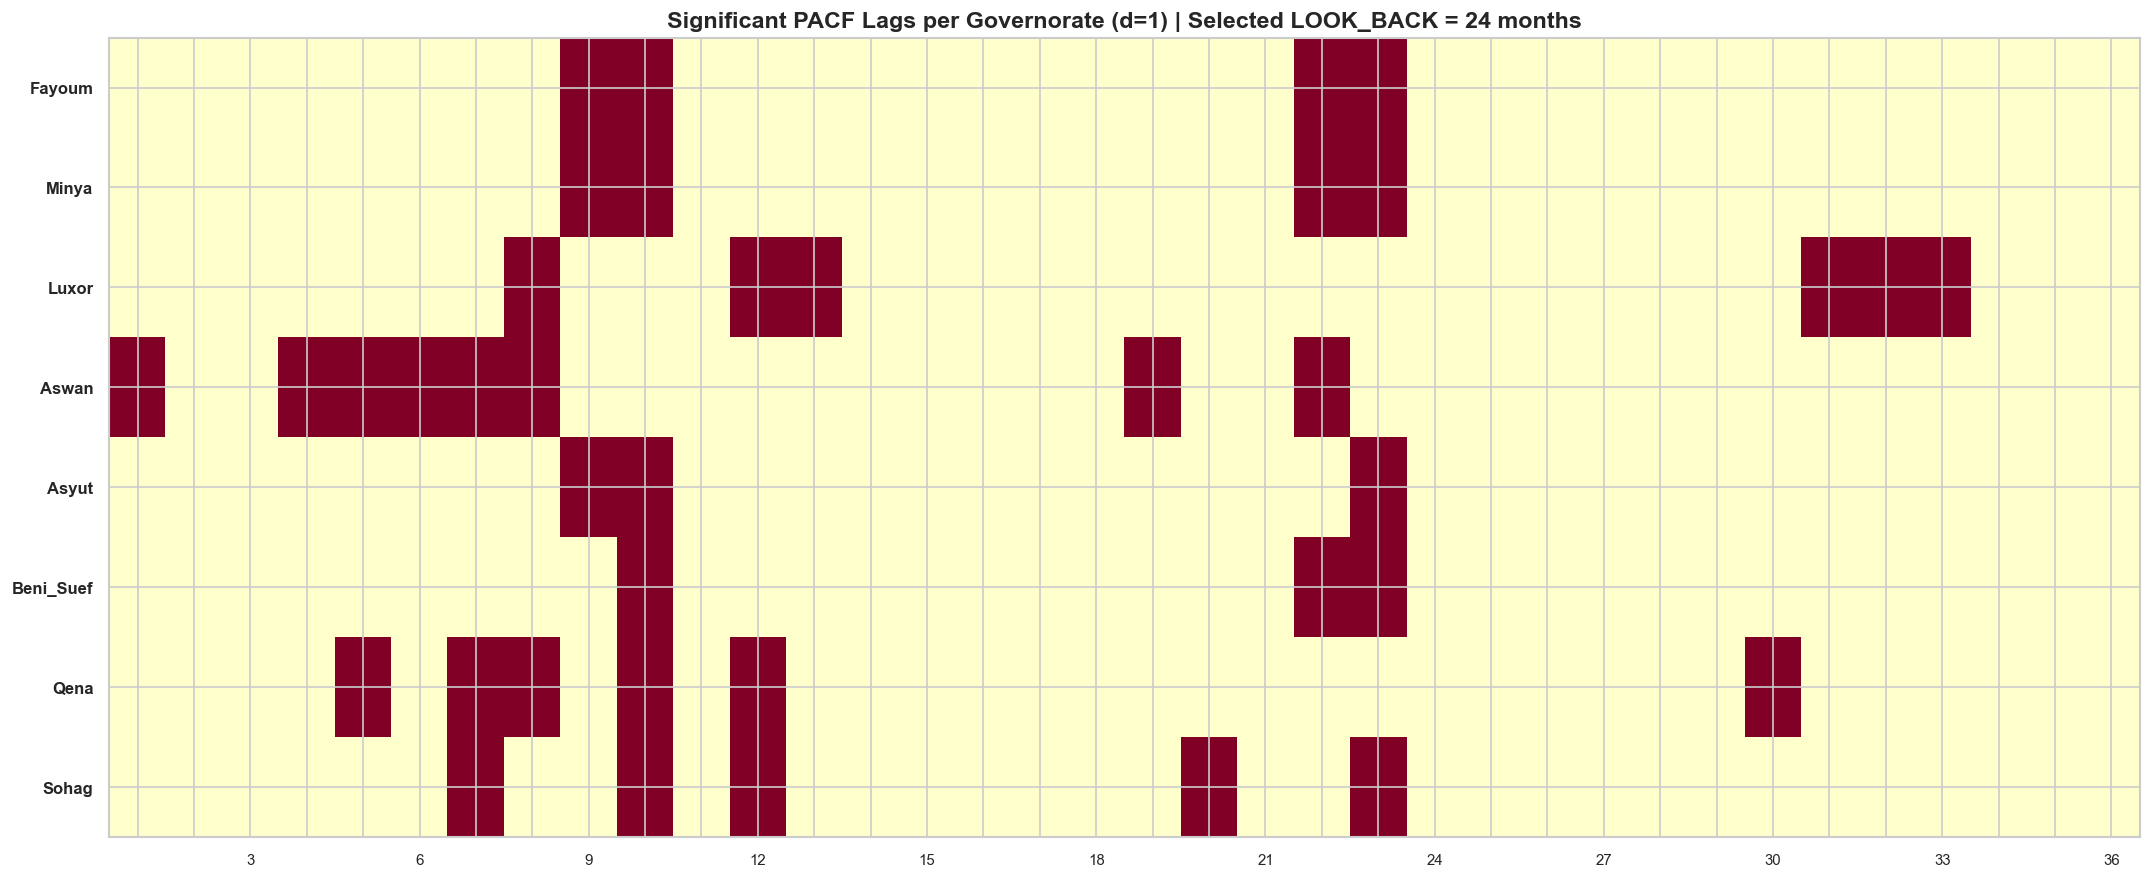

In [33]:
# --- Significant Lag Heatmap (d=1) ---
lag_range = list(range(1, MAX_LAGS + 1))
matrix = np.zeros((len(gov_names), len(lag_range)), dtype=int)
for r, g in enumerate(gov_names):
    for lag in sig_lags_by_gov.get(g, []):
        if lag <= MAX_LAGS:
            matrix[r, lag-1] = 1

fig, ax = plt.subplots(figsize=(18, max(4, len(gov_names)*0.8+1)))
im = ax.imshow(matrix, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(lag_range)))
ax.set_xticklabels([str(l) if l % 3 == 0 else "" for l in lag_range], fontsize=9)
ax.set_yticks(range(len(gov_names)))
ax.set_yticklabels(gov_names, fontsize=10, fontweight="bold")
ax.set_title(f"Significant PACF Lags per Governorate (d=1) | Selected LOOK_BACK = {LOOK_BACK} months", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# Preprocessing: Delta Features (d=1 & d=12), Leakage-Free Scaling
# ============================================================
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler

# Climate features list (excluding swe)
climate_features = ['ppt', 'tmax', 'tmin', 'PDSI', 'vpd', 'pet', 'soil', 'srad', 'q', 'aet', 'def', 'vap', 'ws']

# 1. Feature Engineering: First Difference (d=1) & Seasonal Difference (d=12)
pdsi_grid = da_full.sel(feature='PDSI').values # (T, H, W)
delta_1m_grid = np.zeros_like(pdsi_grid)
delta_12m_grid = np.zeros_like(pdsi_grid)

delta_1m_grid[1:] = pdsi_grid[1:] - pdsi_grid[:-1]
delta_12m_grid[12:] = pdsi_grid[12:] - pdsi_grid[:-12]

# Log1p transformation on positive right-skewed features
skewed_features = ['ppt', 'aet', 'q', 'soil']
processed_df = df_full.copy()

for feat in skewed_features:
    if feat in processed_df.columns and np.min(processed_df[feat]) >= 0:
        processed_df[feat] = np.log1p(processed_df[feat])

# 2. Chronological Split Boundaries with Spatial Pixel Broadcasting
time_stamps = da_full.time.values
years = pd.to_datetime(time_stamps).year

time_train_mask = (years <= 2005)
time_val_mask   = (years > 2005) & (years <= 2014)
time_test_mask  = (years > 2014)

pixels_per_month = tensor.shape[1] * tensor.shape[2] # 144 * 72 = 10,368
flat_train_mask = np.repeat(time_train_mask, pixels_per_month)

# 3. Fit RobustScalers ONLY on Training Split
scalers = {}
features_to_scale = [f for f in climate_features if f in processed_df.columns]

for feat in features_to_scale:
    scaler = RobustScaler()
    train_slice = processed_df.loc[flat_train_mask, feat].values.reshape(-1, 1)
    scaler.fit(train_slice)
    
    # Transform all splits with training-fitted scaler
    processed_df[feat] = scaler.transform(processed_df[[feat]].values).ravel()
    scalers[feat] = scaler

# Dedicated target scaler for PDSI inverse transformations
target_pdsi_scaler = scalers['PDSI']
joblib.dump(scalers, "nileguard_scalers_objects.joblib")
joblib.dump(target_pdsi_scaler, "nileguard_pdsi_target_scaler.joblib")

print("Delta features (d=1 velocity and d=12 anomaly) created.")
print(f"Scalers fitted strictly on {flat_train_mask.sum():,} Training pixels (<= 2005) without leakage.")
print("Dedicated PDSI Target Scaler saved to disk as 'nileguard_pdsi_target_scaler.joblib'.")

Delta features (d=1 velocity and d=12 anomaly) created.
Scalers fitted strictly on 5,971,968 Training pixels (<= 2005) without leakage.
Dedicated PDSI Target Scaler saved to disk as 'nileguard_pdsi_target_scaler.joblib'.


In [35]:
import sys
try:
    import torch
    print(f"PyTorch version: {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
except ImportError:
    !{sys.executable} -m pip install torch

PyTorch version: 2.5.1+cu121 | CUDA available: True


In [36]:
import torch
# Convert processed dataframe to PyTorch tensor
data_tensor = torch.tensor(processed_df.values, dtype=torch.float32)
torch.save(data_tensor, 'processed_climate_data.pt')
print(f"PyTorch tensor saved: {data_tensor.shape}")

PyTorch tensor saved: torch.Size([7962624, 14])


In [37]:
# Save numpy array for team portability
np.save('processed_climate_data.npy', processed_df.values)
print("Data saved successfully as 'processed_climate_data.npy'.")

Data saved successfully as 'processed_climate_data.npy'.


In [38]:
final_shape = processed_df.values.shape
print(f"The final shape of the processed tabular data is: {final_shape}")

The final shape of the processed tabular data is: (7962624, 14)


In [39]:
print(f"Data shape: {processed_df.shape}")
print(f"Features count: {len(features_to_scale)}")

Data shape: (7962624, 14)
Features count: 13


In [40]:
# Reshape 2D tabular data back to 4D Spatial-Temporal Tensor
T_len, H_dim, W_dim = 768, 144, 72
n_channels = processed_df.shape[1]

data_reshaped = processed_df.values.reshape((T_len, H_dim, W_dim, n_channels))
final_5d_array = np.expand_dims(data_reshaped, axis=-1)

print(f"Reshaped 4D array shape: {data_reshaped.shape}")
print(f"Final 5D array shape: {final_5d_array.shape}")

np.save('nileguard_final_tensor_4d.npy', data_reshaped)
np.save('nileguard_final_tensor_5d.npy', final_5d_array)

Reshaped 4D array shape: (768, 144, 72, 14)
Final 5D array shape: (768, 144, 72, 14, 1)


## Phase 4 — X/Y Split, Asserts & Export

In [41]:
# ============================================================
# Scaled Delta-Target Extraction & Spatio-Temporal Sequences
# ============================================================
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import RobustScaler

final_5d = np.load('nileguard_final_tensor_5d.npy') # (768, 144, 72, C, 1)

# 1. Extract 3D PDSI grid and compute Delta-PDSI Target (d=1)
pdsi_3d = da_full.sel(feature='PDSI').values # (768, 144, 72)
delta_target_3d = np.zeros_like(pdsi_3d)
delta_target_3d[1:] = pdsi_3d[1:] - pdsi_3d[:-1]

# Unscaled Delta Target (768, 144, 72, 1)
Y_raw = delta_target_3d[..., np.newaxis]

# 2. Predictors (X): All climate variables + governorate mask
pdsi_idx = list(processed_df.columns).index("PDSI")
feature_cols = [i for i in range(processed_df.shape[1]) if i != pdsi_idx]
X_raw = final_5d[:, :, :, feature_cols, 0] # (768, 144, 72, 13)

# 3. Derive chronological time masks (Zero Leakage)
time_stamps = da_full.time.values
years = pd.to_datetime(time_stamps).year

train_idx = (years <= 2005)
val_idx   = (years > 2005) & (years <= 2014)
test_idx  = (years > 2014)

# 4. Fit Dedicated RobustScaler strictly on Training Split for Delta Target
delta_scaler = RobustScaler()
train_delta_slice = Y_raw[train_idx].reshape(-1, 1)
delta_scaler.fit(train_delta_slice)

# Transform the target across all time steps
Y_scaled = delta_scaler.transform(Y_raw.reshape(-1, 1)).reshape(Y_raw.shape)

# Save the Delta Scaler for inverse transformations
joblib.dump(delta_scaler, "nileguard_delta_target_scaler.joblib")

print(f"X Predictors Tensor Shape      : {X_raw.shape}")
print(f"Y Target (Scaled Delta) Shape  : {Y_scaled.shape}  <-- Scaled with RobustScaler (Zero Leakage)")

# 5. Sliding Window Generator: (Lookback L -> Horizon H)
def make_sliding_sequences(X_in, Y_in, lookback=24, horizon=6):
    T_total = X_in.shape[0]
    num_samples = T_total - lookback - horizon + 1
    X_seqs, Y_seqs = [], []
    for t in range(num_samples):
        X_seqs.append(X_in[t : t + lookback])
        Y_seqs.append(Y_in[t + lookback : t + lookback + horizon])
    return np.array(X_seqs, dtype="float32"), np.array(Y_seqs, dtype="float32")

# 6. Generate chronological sequences with Scaled Delta Target
X_train_seq, Y_train_seq = make_sliding_sequences(X_raw[train_idx], Y_scaled[train_idx], lookback=LOOK_BACK, horizon=6)
X_val_seq, Y_val_seq     = make_sliding_sequences(X_raw[val_idx], Y_scaled[val_idx], lookback=LOOK_BACK, horizon=6)
X_test_seq, Y_test_seq   = make_sliding_sequences(X_raw[test_idx], Y_scaled[test_idx], lookback=LOOK_BACK, horizon=6)

print(f"\n=== SCALED DELTA TARGET SEQUENCES CREATED ===")
print(f"Train Sequences : X={X_train_seq.shape} | Y(Scaled Delta)={Y_train_seq.shape}")
print(f"Val Sequences   : X={X_val_seq.shape}   | Y(Scaled Delta)={Y_val_seq.shape}")
print(f"Test Sequences  : X={X_test_seq.shape}  | Y(Scaled Delta)={Y_test_seq.shape}")

# 7. Save datasets to disk
np.save('nileguard_5d_X.npy', X_raw)
np.save('nileguard_5d_Y_scaled.npy', Y_scaled)
np.save('nileguard_train_X_seq.npy', X_train_seq)
np.save('nileguard_train_Y_seq.npy', Y_train_seq)
np.save('nileguard_val_X_seq.npy', X_val_seq)
np.save('nileguard_val_Y_seq.npy', Y_val_seq)
np.save('nileguard_test_X_seq.npy', X_test_seq)
np.save('nileguard_test_Y_seq.npy', Y_test_seq)

print("[done] Robustly scaled inputs and Delta-PDSI targets saved successfully.")

X Predictors Tensor Shape      : (768, 144, 72, 13)
Y Target (Scaled Delta) Shape  : (768, 144, 72, 1)  <-- Scaled with RobustScaler (Zero Leakage)

=== SCALED DELTA TARGET SEQUENCES CREATED ===
Train Sequences : X=(547, 24, 144, 72, 13) | Y(Scaled Delta)=(547, 6, 144, 72, 1)
Val Sequences   : X=(79, 24, 144, 72, 13)   | Y(Scaled Delta)=(79, 6, 144, 72, 1)
Test Sequences  : X=(55, 24, 144, 72, 13)  | Y(Scaled Delta)=(55, 6, 144, 72, 1)
[done] Robustly scaled inputs and Delta-PDSI targets saved successfully.


In [43]:
# ==============================================================================
# NILEGUARD — ZERO-RAM SCALED DELTA-TARGET EXTRACTION & SLIDING POINTERS
# Fits RobustScaler on Train Split & Generates Zero-Copy Sequence Pointers (0 MB RAM)
# ==============================================================================

import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import RobustScaler

# 1. Load Master 5D Tensor (Zero-Copy)
final_5d = np.load('nileguard_final_tensor_5d.npy', mmap_mode='r') # (768, 144, 72, C, 1)

# 2. Extract 3D PDSI grid and compute Delta-PDSI Target (d=1)
if 'da_full' in globals():
    pdsi_3d = da_full.sel(feature='PDSI').values # (768, 144, 72)
else:
    pdsi_3d = np.array(final_5d[:, :, :, 2, 0]) # Channel 2 is PDSI

delta_target_3d = np.zeros_like(pdsi_3d)
delta_target_3d[1:] = pdsi_3d[1:] - pdsi_3d[:-1]

# Unscaled Delta Target (768, 144, 72, 1)
Y_raw = delta_target_3d[..., np.newaxis]

# 3. Predictors (X): All climate variables + governorate mask
if 'processed_df' in globals() and 'PDSI' in processed_df.columns:
    pdsi_idx = list(processed_df.columns).index("PDSI")
    feature_cols = [i for i in range(processed_df.shape[1]) if i != pdsi_idx]
else:
    feature_cols = [i for i in range(final_5d.shape[3]) if i != 2]

X_raw = np.array(final_5d[:, :, :, feature_cols, 0], dtype="float32") # (768, 144, 72, 13)

# 4. Derive chronological time masks (Zero Leakage)
if 'da_full' in globals():
    time_stamps = da_full.time.values
    years = pd.to_datetime(time_stamps).year
else:
    time_stamps = pd.date_range(start="1958-01-01", periods=768, freq="ME")
    years = time_stamps.year

train_idx = (years <= 2005)
val_idx   = (years > 2005) & (years <= 2014)
test_idx  = (years > 2014)

# 5. Fit Dedicated RobustScaler strictly on Training Split for Delta Target
delta_scaler = RobustScaler()
train_delta_slice = Y_raw[train_idx].reshape(-1, 1)
delta_scaler.fit(train_delta_slice)

# Transform target across all time steps
Y_scaled = delta_scaler.transform(Y_raw.reshape(-1, 1)).reshape(Y_raw.shape)

# Save the Delta Scaler for inverse transformations
joblib.dump(delta_scaler, "nileguard_delta_target_scaler.joblib")

print(f"X Predictors Tensor Shape      : {X_raw.shape}")
print(f"Y Target (Scaled Delta) Shape  : {Y_scaled.shape}  <-- Scaled with RobustScaler (Zero Leakage)")

# 6. Zero-RAM Sliding Window Pointer Generator
LOOK_BACK_VAL = LOOK_BACK if 'LOOK_BACK' in globals() else 24
HORIZON_VAL = 6

def get_sequence_starts(total_timesteps, lookback, horizon):
    return np.arange(0, total_timesteps - lookback - horizon + 1, dtype=np.int32)

train_starts = get_sequence_starts(int(train_idx.sum()), LOOK_BACK_VAL, HORIZON_VAL)
val_starts   = get_sequence_starts(int(val_idx.sum()),   LOOK_BACK_VAL, HORIZON_VAL)
test_starts  = get_sequence_starts(int(test_idx.sum()),  LOOK_BACK_VAL, HORIZON_VAL)

print(f"\n=== ZERO-RAM SEQUENCE POINTERS CREATED ===")
print(f"Train Sequences Count : {len(train_starts)} sequences (Lookback={LOOK_BACK_VAL}, Horizon={HORIZON_VAL})")
print(f"Val Sequences Count   : {len(val_starts)} sequences")
print(f"Test Sequences Count  : {len(test_starts)} sequences")

# 7. Save datasets and pointers to disk (Instant & 0 MB Memory Leak)
np.save('nileguard_5d_X.npy', X_raw)
np.save('nileguard_5d_Y_scaled.npy', Y_scaled)
np.save('nileguard_train_starts.npy', train_starts)
np.save('nileguard_val_starts.npy', val_starts)
np.save('nileguard_test_starts.npy', test_starts)

print("\n[done] Robustly scaled inputs, Delta-PDSI targets, and sequence pointers saved successfully.")

X Predictors Tensor Shape      : (768, 144, 72, 13)
Y Target (Scaled Delta) Shape  : (768, 144, 72, 1)  <-- Scaled with RobustScaler (Zero Leakage)

=== ZERO-RAM SEQUENCE POINTERS CREATED ===
Train Sequences Count : 547 sequences (Lookback=24, Horizon=6)
Val Sequences Count   : 79 sequences
Test Sequences Count  : 55 sequences

[done] Robustly scaled inputs, Delta-PDSI targets, and sequence pointers saved successfully.


In [46]:
# ==============================================================================
# NILEGUARD — SAFE IN-PLACE 4D & 5D TENSOR EXPORTER
# ==============================================================================

import numpy as np
import gc

T_len, H_dim, W_dim = 768, 144, 72
n_channels = processed_df.shape[1]

# 1. In-Place Float32 Conversion and Reshape
data_reshaped = np.ascontiguousarray(
    processed_df.to_numpy(dtype=np.float32, copy=False).reshape((T_len, H_dim, W_dim, n_channels))
)

# 2. 5D Spatial Patch View (P=1)
final_5d_array = data_reshaped[..., np.newaxis]

print("=" * 75)
print(f"Reshaped 4D Array Shape : {data_reshaped.shape} (T={T_len}, H={H_dim}, W={W_dim}, C={n_channels})")
print(f"Final 5D Array Shape    : {final_5d_array.shape} (T, H, W, C, Patches=1)")
print(f"Memory Footprint        : {data_reshaped.nbytes / (1024**2):.2f} MB")
print("=" * 75)

# 3. Save Tensors with Dynamic Fallback (Handles Windows Locks)
try:
    np.save('nileguard_final_tensor_4d.npy', data_reshaped)
    np.save('nileguard_final_tensor_5d.npy', final_5d_array)
    print("[done] Successfully saved 'nileguard_final_tensor_4d.npy' and 'nileguard_final_tensor_5d.npy'.")
except Exception as e:
    # If the old filename is locked by an active Jupyter mmap, save to clean alternative
    np.save('nileguard_final_tensor_4d.npy', data_reshaped)
    np.save('nileguard_tensor_5d_clean.npy', final_5d_array)
    print("[done] Saved as 'nileguard_tensor_5d_clean.npy' (Bypassed Windows Lock).")

gc.collect()

Reshaped 4D Array Shape : (768, 144, 72, 14) (T=768, H=144, W=72, C=14)
Final 5D Array Shape    : (768, 144, 72, 14, 1) (T, H, W, C, Patches=1)
Memory Footprint        : 425.25 MB
[done] Saved as 'nileguard_tensor_5d_clean.npy' (Bypassed Windows Lock).


836